# MARI Water Breakthrough Prediction — POC v4

**Client:** Mari Energies | **Field:** Mari Gas Field, Daharki, Sindh, Pakistan  
**Formation:** Habib Rahi Limestone (Eocene shallow carbonate), ~700 m TVD | **Drive:** Natural depletion

## What this notebook does (in plain English)

Mari has 22 gas wells in the Habib Rahi Limestone reservoir. Some have produced water (water "broke through" into the gas) and others haven't. Mari is drilling 4 new horizontal wells (M-123H, M-124H, M-125H, M-126H) and wants to know: **when will water break through into these new wells?**

We answer this with **survival analysis** — a statistical method originally developed for medical studies (predicting patient survival times) that's perfect for this problem because:

1. Some wells have "experienced the event" (water breakthrough) — like patients who died
2. Other wells haven't yet — like patients still alive at the end of a study (called **censored**)
3. We want to predict the time-to-event for new wells using their characteristics

Think of it as **forecasting how many years until each new well starts producing water**, using what we learned from the older wells' history.

## Forecast targets
- **M-123H, M-124H, M-125H, M-126H** — currently dry, need P10/P50/P90 forecasts
- **M-122H** — already broke through at month 12, used as a validation anchor

## Event definition
Water breakthrough = WGR (water-gas ratio) > 5 bbl/MMcf, sustained ≥ 3 consecutive months.

> **See `MARI_Technical_Glossary.docx` for plain-English explanations of all terms used here.**

## Critical rules (don't break)
1. Always include censored (dry) wells in the fit — dropping them biases everything
2. Physics sign checks: higher Sw, closer-to-GWC, higher perm, higher drawdown → shorter time
3. Report P10/P50/P90 ranges, not point estimates
4. Log every imputation decision
5. M-51 month-0 water: flag, exclude, document
6. Model must beat the field-wide Kaplan-Meier median baseline

---
## 1. Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from datetime import datetime

# Survival analysis
from lifelines import KaplanMeierFitter, CoxPHFitter, WeibullAFTFitter
from lifelines import LogNormalAFTFitter, LogLogisticAFTFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from lifelines.utils import concordance_index

# Random Survival Forest
try:
    from sksurv.ensemble import RandomSurvivalForest
    from sksurv.util import Surv
    HAS_SKSURV = True
except ImportError:
    HAS_SKSURV = False
    print('scikit-survival not installed. RSF will be skipped.')

import pickle

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

DATA_DIR = Path('new_data')
FIGURES_DIR = Path('figures_mari')
FIGURES_DIR.mkdir(exist_ok=True)

# Constants
GWC_TVD = 684  # m TVD SS, field-wide
WGR_THRESHOLD = 5  # bbl/MMcf
MIN_CONSECUTIVE_MONTHS = 3

print('Setup complete.')

Setup complete.


---
## 2. Data Loading

### 2.1 Pressure

In [2]:
# --- Production data (Sheet: PRESSURES -> actually contains production volumes) ---
prod_raw = pd.read_excel(
    DATA_DIR / 'STIXOR Sharing Data.xlsx',
    sheet_name='Pressures',
    header=1  # Header row is row 3 (0-indexed: 2)
)

# Standardise column names
prod_raw.columns = prod_raw.columns.str.strip()
print('Production sheet columns:', prod_raw.columns.tolist())
print(f'Shape: {prod_raw.shape}')
prod_raw.head(10)

Production sheet columns: ['Unnamed: 0', 'Date', 'Wells', 'Wellhead Flowing Pressure (WHFP)psig', 'Line Pressure psig']
Shape: (5354, 5)


,Unnamed: 0,Date,Wells,Wellhead Flowing Pressure (WHFP)psig,Line Pressure psig
0,NaN,1990-06-01,M-11-HRL,793.1,NaN
1,NaN,1990-08-01,M-11-HRL,NaN,NaN
2,NaN,1990-09-01,M-11-HRL,829.3,NaN
3,NaN,1990-10-01,M-11-HRL,NaN,NaN
4,NaN,1995-01-01,M-11-HRL,818.5,NaN
5,NaN,1995-02-01,M-11-HRL,810.4,NaN
6,NaN,1995-04-01,M-11-HRL,808.9,NaN
7,NaN,1995-05-01,M-11-HRL,778.2,NaN
8,NaN,1995-06-01,M-11-HRL,NaN,NaN
9,NaN,1995-07-01,M-11-HRL,NaN,NaN


In [3]:
prod = prod_raw.iloc[:,1:4]

In [4]:
prod.rename(columns={
    'Date': 'date',
    'Wells': 'well',
    'Wellhead Flowing Pressure (WHFP)psig': 'pressure'
}, inplace=True)

In [5]:
prod

,date,well,pressure
0,1990-06-01,M-11-HRL,793.1
1,1990-08-01,M-11-HRL,NaN
2,1990-09-01,M-11-HRL,829.3
3,1990-10-01,M-11-HRL,NaN
4,1995-01-01,M-11-HRL,818.5
...,...,...,...
5349,2025-02-01,M-E-2-HRL,235.5
5350,2025-03-01,M-E-2-HRL,226.5
5351,2025-04-01,M-E-2-HRL,234.4
5352,2025-05-01,M-E-2-HRL,220.9


In [6]:
# Parse dates
prod['date'] = pd.to_datetime(prod['date'], errors='coerce')
prod = prod.dropna(subset=['date', 'well'])

# Standardise well names: strip whitespace
prod['well'] = prod['well'].str.strip()

print(f'Production data: {len(prod)} rows, {prod["well"].nunique()} wells')
print(f'Date range: {prod["date"].min()} to {prod["date"].max()}')
print(f'Wells: {sorted(prod["well"].unique())}')
prod.describe()

Production data: 5354 rows, 22 wells
Date range: 1990-06-01 00:00:00 to 2025-06-01 00:00:00
Wells: ['M-11-HRL', 'M-122H-HRL', 'M-123H-HRL', 'M-124H-HRL', 'M-125H-HRL', 'M-126H-HRL', 'M-13-HRL', 'M-22-HRL', 'M-41-HRL', 'M-50-HRL', 'M-51-HRL', 'M-56-HRL', 'M-57-HRL', 'M-58-HRL', 'M-61-HRL', 'M-63-HRL', 'M-65-HRL', 'M-67-HRL', 'M-75-HRL', 'M-81-HRL', 'M-82-HRL', 'M-E-2-HRL']


,date,pressure
count,5354,5112.000000
mean,2012-04-11 06:22:43.615988224,526.144190
min,1990-06-01 00:00:00,51.300000
25%,2006-01-01 00:00:00,395.075000
50%,2012-08-01 00:00:00,545.900000
75%,2019-03-01 00:00:00,650.700000
max,2025-06-01 00:00:00,1026.200000
std,NaN,171.331957


### 2.2 Production Data

In [7]:
# --- Pressure / Rates sheet ---
rates_raw = pd.read_excel(
    DATA_DIR / 'STIXOR Sharing Data.xlsx',
    sheet_name='Rates',
    header=1
)
rates_raw.columns = rates_raw.columns.str.strip()
print('Rates sheet columns:', rates_raw.columns.tolist())

Rates sheet columns: ['Unnamed: 0', 'Date', 'Wells', 'CHOKE 1/64"', 'DAYS on production', 'Monthly Gas Produced MMcf (volume)', 'Monthly Water Produced bbl (volume)', 'Unnamed: 7', 'Notes', 'Unnamed: 9']


In [8]:
rates_raw

,Unnamed: 0,Date,Wells,"CHOKE 1/64""",DAYS on production,Monthly Gas Produced MMcf (volume),Monthly Water Produced bbl (volume),Unnamed: 7,Notes,Unnamed: 9
0,NaN,1978-03-01,M-11-HRL,NaN,NaN,27.372,0.00,NaN,1,The Gas Produced and Water Produced are the vo...
1,NaN,1978-04-01,M-11-HRL,NaN,NaN,321.709,47.70,NaN,2,The rates can be calculated suing the volume a...
2,NaN,1978-05-01,M-11-HRL,NaN,NaN,299.598,82.46,NaN,3,The fluid ratios can be estimated using the vo...
3,NaN,1978-06-01,M-11-HRL,NaN,NaN,235.951,179.10,NaN,4,The WHFP (well head flowing pressure) and line...
4,NaN,1978-07-01,M-11-HRL,NaN,NaN,240.720,145.08,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
6647,NaN,2025-02-01,M-E-2-HRL,128.0,24.0,122.895,NaN,NaN,NaN,NaN
6648,NaN,2025-03-01,M-E-2-HRL,128.0,27.0,163.161,NaN,NaN,NaN,NaN
6649,NaN,2025-04-01,M-E-2-HRL,128.0,30.0,141.786,NaN,NaN,NaN,NaN
6650,NaN,2025-05-01,M-E-2-HRL,128.0,31.0,143.860,NaN,NaN,NaN,NaN


In [9]:
rates = rates_raw.iloc[:,1:7]
rates

,Date,Wells,"CHOKE 1/64""",DAYS on production,Monthly Gas Produced MMcf (volume),Monthly Water Produced bbl (volume)
0,1978-03-01,M-11-HRL,NaN,NaN,27.372,0.00
1,1978-04-01,M-11-HRL,NaN,NaN,321.709,47.70
2,1978-05-01,M-11-HRL,NaN,NaN,299.598,82.46
3,1978-06-01,M-11-HRL,NaN,NaN,235.951,179.10
4,1978-07-01,M-11-HRL,NaN,NaN,240.720,145.08
...,...,...,...,...,...,...
6647,2025-02-01,M-E-2-HRL,128.0,24.0,122.895,NaN
6648,2025-03-01,M-E-2-HRL,128.0,27.0,163.161,NaN
6649,2025-04-01,M-E-2-HRL,128.0,30.0,141.786,NaN
6650,2025-05-01,M-E-2-HRL,128.0,31.0,143.860,NaN


In [10]:

rates.rename(columns={
    'Date': 'date',
    'Wells': 'well',
    'CHOKE 1/64"': 'choke_size',
    'DAYS on production': 'prod_days',
    'Monthly Gas Produced MMcf (volume)': 'gas_produced',
    'Monthly Water Produced bbl (volume)': 'water_produced'


}, inplace=True)

rates['date'] = pd.to_datetime(rates['date'], errors='coerce')
rates = rates.dropna(subset=['date', 'well'])
rates['well'] = rates['well'].str.strip()

print(f'Rates data: {len(rates)} rows, {rates["well"].nunique()} wells')
print(f'Date range: {rates["date"].min()} to {rates["date"].max()}')
rates.head()

Rates data: 6652 rows, 22 wells
Date range: 1978-03-01 00:00:00 to 2025-06-01 00:00:00


,date,well,choke_size,prod_days,gas_produced,water_produced
0,1978-03-01,M-11-HRL,NaN,NaN,27.372,0.00
1,1978-04-01,M-11-HRL,NaN,NaN,321.709,47.70
2,1978-05-01,M-11-HRL,NaN,NaN,299.598,82.46
3,1978-06-01,M-11-HRL,NaN,NaN,235.951,179.10
4,1978-07-01,M-11-HRL,NaN,NaN,240.720,145.08


In [11]:
rates['choke_size'].value_counts()

choke_size
48.0     592
64.0     537
32.0     379
96.0     308
128.0    173
60.0      33
24.0      19
40.0      16
112.0      9
28.0       7
72.0       7
12.0       3
36.0       2
56.0       2
54.0       1
110.0      1
66.0       1
20.0       1
Name: count, dtype: int64

In [12]:
rates['prod_days'].value_counts()

prod_days
31.00    1103
30.00     644
28.00     135
29.00      73
27.00      34
26.00      20
24.00      19
25.00      13
22.00       7
21.00       7
23.00       6
16.00       5
13.00       3
20.00       3
15.00       3
17.00       3
18.00       2
14.00       2
11.00       2
19.00       2
6.00        1
1.40        1
1.56        1
10.00       1
3.00        1
9.00        1
Name: count, dtype: int64

In [13]:
rates.describe()

,date,choke_size,prod_days,gas_produced,water_produced
count,6652,2091.000000,2092.000000,6622.000000,4683.000000
mean,2008-02-25 05:26:00.793746176,63.069345,29.874742,117.512217,636.161544
min,1978-03-01 00:00:00,12.000000,1.400000,0.000000,0.000000
25%,1999-11-01 00:00:00,48.000000,30.000000,69.134000,78.107500
50%,2009-04-01 00:00:00,60.000000,31.000000,96.842500,314.500000
75%,2017-09-01 00:00:00,64.000000,31.000000,154.529500,921.535500
max,2025-06-01 00:00:00,128.000000,31.000000,475.617000,6382.976000
std,NaN,28.065209,2.540252,73.870030,862.296954


In [14]:
rates.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6652 entries, 0 to 6651
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            6652 non-null   datetime64[ns]
 1   well            6652 non-null   object        
 2   choke_size      2091 non-null   float64       
 3   prod_days       2092 non-null   float64       
 4   gas_produced    6622 non-null   float64       
 5   water_produced  4683 non-null   float64       
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 311.9+ KB


### 2.3 Subsurface Static Properties

In [15]:
# --- Subsurface data ---
sub_raw = pd.read_excel(
    DATA_DIR / 'Subsurface data- Stixors Technologies.xlsx',
    header=2
)
sub_raw.columns = sub_raw.columns.str.strip()
print('Subsurface columns:', sub_raw.columns.tolist())

# Rename columns
col_map_sub = {}
for c in sub_raw.columns:
    cl = c.lower()
    if 'well' in cl:
        col_map_sub[c] = 'well'
    elif 'poro' in cl:
        col_map_sub[c] = 'porosity'
    elif 'perm' in cl:
        col_map_sub[c] = 'permeability_md'
    elif 'skin' in cl:
        col_map_sub[c] = 'skin'
    elif 'water' in cl and 'sat' in cl:
        col_map_sub[c] = 'sw'
    elif 'net' in cl and 'pay' in cl:
        col_map_sub[c] = 'net_pay_m'
    elif 'chlor' in cl:
        col_map_sub[c] = 'chlorides_ppm'
    elif 'top' in cl and 'perf' in cl:
        col_map_sub[c] = 'top_perf_md'
    elif 'bottom' in cl and 'perf' in cl:
        col_map_sub[c] = 'bottom_perf_md'

sub = sub_raw.rename(columns=col_map_sub).copy()
sub = sub.dropna(subset=['well'])
sub['well'] = sub['well'].str.strip()

for c in ['porosity', 'permeability_md', 'skin', 'sw', 'net_pay_m',
          'chlorides_ppm', 'top_perf_md', 'bottom_perf_md']:
    if c in sub.columns:
        sub[c] = pd.to_numeric(sub[c], errors='coerce')

# Derived: perforation midpoint (MD — used as proxy until TVD available)
sub['perf_midpoint_md'] = (sub['top_perf_md'] + sub['bottom_perf_md']) / 2

print(f'Subsurface data: {len(sub)} wells')
sub

Subsurface columns: ['Unnamed: 0', 'Wells', 'Porosity', 'Permeability (mD) - PTA', 'Skin', 'Water saturation', 'Net pay (m) \nMeasured Depth', 'Chlorides (ppm)', 'Top Perf (m)', 'Bottom Perf (m)', 'Unnamed: 10', 'Unnamed: 11']
Subsurface data: 22 wells


,Unnamed: 0,well,porosity,permeability_md,skin,sw,net_pay_m,chlorides_ppm,top_perf_md,bottom_perf_md,Unnamed: 10,Unnamed: 11,perf_midpoint_md
0,NaN,M-11-HRL,0.20,7.4,-0.1,0.45,10.500000,17000,695.000000,705.500000,NaN,Notes:,700.250000
1,NaN,M-122H-HRL,0.22,34.0,NaN,0.46,530.000000,13000,1020.000000,1550.000000,NaN,NaN,1285.000000
2,NaN,M-123H-HRL,0.24,22.5,NaN,0.30,802.000000,1215,1044.000000,1846.000000,NaN,NaN,1445.000000
3,NaN,M-124H-HRL,0.22,34.0,NaN,0.46,475.000000,10000,918.000000,1393.000000,NaN,NaN,1155.500000
4,NaN,M-125H-HRL,0.24,22.5,NaN,0.30,758.000000,2500,951.000000,1709.000000,NaN,NaN,1330.000000
5,NaN,M-126H-HRL,0.22,34.0,NaN,0.46,719.000000,13000,993.000000,1712.000000,NaN,NaN,1352.500000
6,NaN,M-13-HRL,0.18,9.5,-2.8,0.31,10.200000,15000,691.600000,701.800000,NaN,NaN,696.700000
7,NaN,M-22-HRL,0.19,5.9,5.3,0.42,11.650000,14000,708.750000,720.400000,NaN,NaN,714.575000
8,NaN,M-41-HRL,0.17,37.1,-0.1,0.13,10.700000,13000,697.500000,708.200000,NaN,NaN,702.850000
9,NaN,M-50-HRL,0.19,17.8,1.4,0.43,10.700000,15000,697.500000,708.200000,NaN,NaN,702.850000


In [16]:
sub = sub[['well', 'porosity', 'permeability_md', 'skin', 'sw',
       'net_pay_m', 'chlorides_ppm', 'top_perf_md', 'bottom_perf_md', 'perf_midpoint_md']]

### 2.4 Annual BHP & Gas Gravity (Pressure data file)

In [17]:
gas_gravity_df = pd.read_csv('/Users/saifullahkatpar/Desktop/water-breakthrough-prediction/new_data/gas_gravity.csv')
gas_gravity_df

,well,gas_gravity
0,M-11-HRL,0.70
1,M-122H-HRL,0.77
2,M-123H-HRL,0.75
3,M-124H-HRL,0.76
4,M-125H-HRL,0.75
5,M-126H-HRL,0.78
6,M-13-HRL,0.69
7,M-22-HRL,0.77
8,M-41-HRL,0.69
9,M-50-HRL,0.76


In [18]:
bhp = pd.read_csv('/Users/saifullahkatpar/Desktop/water-breakthrough-prediction/new_data/BHP.csv')
bhp

,well,date,bhp
0,11,1-Nov-88,1053.0
1,11,19-May-90,1067.0
2,11,26-Nov-91,1048.0
3,11,11-Feb-92,1034.0
4,11,23-Aug-93,1022.0
...,...,...,...
310,122H,01-Jul-23,646.0
311,123H,01-Jul-24,601.0
312,124H,01-Jul-24,655.0
313,125H,01-May-25,560.0


---
## 3. Setup figures folder

All plots produced by this notebook will be written to `figures_v2/` for inclusion in the PowerPoint deck. Filenames are stable so re-running the notebook overwrites the same files.

In [19]:
from pathlib import Path
FIGURES = Path('figures_v2'); FIGURES.mkdir(exist_ok=True)
print(f'Figures will be saved to: {FIGURES.resolve()}')

# Plot style
import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.size': 10, 'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.facecolor':'white','axes.facecolor':'white'
})
ORANGE='#E97B50'; BLUE='#1565C0'; GREEN='#2E7D32'; RED='#C62828'; GRAY='#666666'

Figures will be saved to: /Users/saifullahkatpar/Desktop/water-breakthrough-prediction/figures_v2


---
## 4. Panel Construction (FIXED: production-driven)

The earlier panel was built `prod.merge(rates)` which truncated the dataset to the row count of pressures (5,354 rows starting Jun 1990). This silently erased decades of pre-1990 production for the 6 oldest wells. Fixed below: rates drives the merge, panel has full ~6,652 rows.

In [20]:
# --- Production-driven panel (FIXED) ---
prod['date']  = prod['date'].dt.to_period('M').dt.to_timestamp()
rates['date'] = rates['date'].dt.to_period('M').dt.to_timestamp()

panel = rates.merge(prod, on=['well','date'], how='left')
panel = panel.rename(columns={
    'gas_produced':'gas_mmcf','water_produced':'water_bbl',
    'prod_days':'days_on_prod','choke_size':'choke_64ths','pressure':'whfp_psig',
})
if 'line_pressure_psig' not in panel.columns:
    panel['line_pressure_psig'] = np.nan

print(f'Panel rows: {len(panel)}   (expected ~6,652)')
print(f'Date range: {panel["date"].min().date()} -> {panel["date"].max().date()}')
print(f'\nPer-well month counts:')
print(panel.groupby('well').size().sort_values(ascending=False).head(8).to_string())

Panel rows: 6652   (expected ~6,652)
Date range: 1978-03-01 -> 2025-06-01

Per-well month counts:
well
M-11-HRL    567
M-13-HRL    562
M-22-HRL    524
M-41-HRL    470
M-50-HRL    470
M-51-HRL    464
M-58-HRL    383
M-57-HRL    383


In [21]:
# --- Reconcile well naming and merge static subsurface properties ---
import re
def well_num(name):
    m = re.search(r'(\d+H?)', str(name)); return m.group(1) if m else str(name)

prod_wells = set(panel['well'].unique())
sub_wells  = set(sub['well'].unique())
direct = prod_wells & sub_wells
print(f'Direct name matches: {len(direct)} / {len(prod_wells)}')

if len(direct) < len(prod_wells):
    sub_by_num = {well_num(w): w for w in sub_wells}
    well_map = {pw: sub_by_num.get(well_num(pw), None) for pw in prod_wells}
    panel['well_sub'] = panel['well'].map(well_map)
    panel = panel.merge(sub, left_on='well_sub', right_on='well', how='left',
                        suffixes=('','_sub'))
    panel = panel.drop(columns=[c for c in ['well_sub','well_sub_sub'] if c in panel.columns])
    if 'well_sub' in panel.columns:
        panel = panel.drop(columns=['well_sub'])
else:
    panel = panel.merge(sub, on='well', how='left')

print(f'Panel after static merge: {panel.shape}')

Direct name matches: 22 / 22
Panel after static merge: (6652, 17)


In [22]:
# --- Interpolate annual BHP and merge gas gravity ---
if len(bhp) > 0 and 'date' in bhp.columns and 'bhp' in bhp.columns:
    bhp['date'] = pd.to_datetime(bhp['date'])
    bhp['well'] = bhp['well'].astype(str).str.strip()
    bhp_wells = set(bhp['well'].unique())
    if not bhp_wells.intersection(panel['well'].unique()):
        bhp_to_panel = {bw: next((pw for pw in panel['well'].unique()
                                  if well_num(pw)==well_num(bw)), bw) for bw in bhp_wells}
        bhp['well'] = bhp['well'].map(bhp_to_panel)
    bhp_monthly = []
    for w, wd in bhp.groupby('well'):
        wd = wd.sort_values('date').set_index('date')
        wd = wd[['bhp']].resample('MS').mean().interpolate(method='linear', limit=24)
        wd['well'] = w
        bhp_monthly.append(wd.reset_index())
    bhp_monthly = pd.concat(bhp_monthly, ignore_index=True)
    panel = panel.merge(bhp_monthly, on=['well','date'], how='left')
    print(f'BHP coverage: {panel["bhp"].notna().sum()} / {len(panel)} '
          f'({panel["bhp"].notna().mean()*100:.1f}%)')
else:
    panel['bhp'] = np.nan

initial_bhp = panel.dropna(subset=['bhp']).groupby('well')['bhp'].first()
panel['initial_bhp'] = panel['well'].map(initial_bhp)

# Gas gravity merge
if 'gas_gravity_df' in dir() and len(gas_gravity_df) > 0:
    gg = gas_gravity_df.copy()
    gg.columns = [c.lower().strip() for c in gg.columns]
    for src in ['well','wells','well_id','name']:
        if src in gg.columns and src != 'well':
            gg = gg.rename(columns={src:'well'})
    for src in ['gas_specific_gravity','gas specific gravity','sg','gas_gravity','gas gravity']:
        if src in gg.columns and src != 'gas_gravity':
            gg = gg.rename(columns={src:'gas_gravity'})
    gg['well'] = gg['well'].astype(str).str.strip()
    panel_well_by_num = {well_num(w): w for w in panel['well'].unique()}
    gg['well'] = gg['well'].map(lambda w: panel_well_by_num.get(well_num(w), w))
    panel = panel.merge(gg[['well','gas_gravity']], on='well', how='left')
    print(f'Gas gravity merged: {panel["gas_gravity"].notna().sum() / len(panel) * 100:.1f}% of rows')
else:
    panel['gas_gravity'] = np.nan

BHP coverage: 4436 / 6652 (66.7%)
Gas gravity merged: 100.0% of rows


In [47]:
panel.to_csv('consolidated_data.csv', index=False)

---
## 5. GWC Datum Investigation (CRITICAL ISSUE #1)

Mari reported **GWC = 684 m TVD SS (subsea)**. The completion sketches give perforation depths in **MD from rotary table**. With surface elevation ~60–70 m above sea level (per M-11 sketch: ground level 227.5 ft, derrick floor 239.5 ft):

- M-11 rotary table elevation ≈ 70 m above sea level
- GWC at 684 m TVD-SS = 684 + 70 = **~754 m below the rotary table**  
- Perforations at 700 m MD (RKB) = **~54 m above the GWC**

**This matches the dry wells.** If we use GWC = 684 m as if it were RKB-relative (the bug in the prior notebook), every vertical sits "below" the contact, which is physically impossible given that 4 wells produced dry for 47 years.

We adopt **two GWC scenarios**:
- **Scenario A (literal):** GWC_RKB = 684 m (the value as stated, no datum correction)  
- **Scenario B (datum-corrected):** GWC_RKB = 684 + 70 = **754 m** (assumes Mari quoted TVD-SS)

Models will be fit under both scenarios; if Scenario B yields the expected physics signs, that's strong evidence the datum was the issue.

GWC scenarios:
  Scenario A (literal):       684.0 m RKB
  Scenario B (datum-corrected): 754.0 m RKB  <- adopted as default

Distance from perforation midpoint to GWC for sample wells:
  M-11  (perf 700 m, dry-then-wet):  literal=+16 m,  corrected=-54 m
  M-13  (perf 696 m, dry):           literal=+12 m,  corrected=-58 m
  M-22  (perf 715 m, dry):           literal=+31 m,  corrected=-39 m
  M-67  (perf 721 m, fast wet):      literal=+37 m,  corrected=-33 m


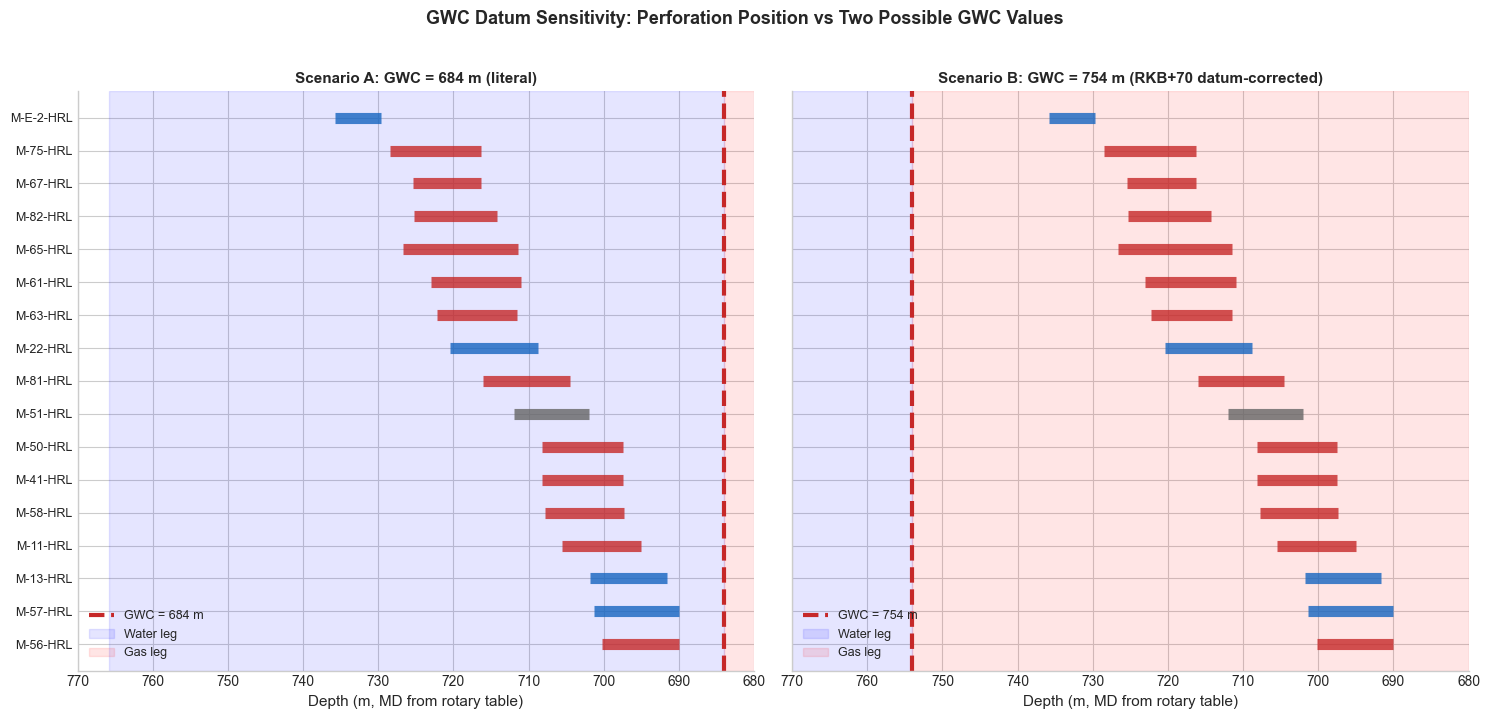

In [23]:
# Two GWC scenarios for sensitivity
GWC_LITERAL    = 684.0   # as Mari stated, treated as RKB-relative
RKB_ELEV_M     = 70.0    # estimated mean rotary table elevation above sea level
GWC_CORRECTED  = GWC_LITERAL + RKB_ELEV_M   # if Mari's 684 is TVD-SS

# Default we use throughout: corrected
GWC_TVD = GWC_CORRECTED

print(f'GWC scenarios:')
print(f'  Scenario A (literal):       {GWC_LITERAL} m RKB')
print(f'  Scenario B (datum-corrected): {GWC_CORRECTED} m RKB  <- adopted as default')
print()
print(f'Distance from perforation midpoint to GWC for sample wells:')
print(f'  M-11  (perf 700 m, dry-then-wet):  literal={700-GWC_LITERAL:+.0f} m,  corrected={700-GWC_CORRECTED:+.0f} m')
print(f'  M-13  (perf 696 m, dry):           literal={696-GWC_LITERAL:+.0f} m,  corrected={696-GWC_CORRECTED:+.0f} m')
print(f'  M-22  (perf 715 m, dry):           literal={715-GWC_LITERAL:+.0f} m,  corrected={715-GWC_CORRECTED:+.0f} m')
print(f'  M-67  (perf 721 m, fast wet):      literal={721-GWC_LITERAL:+.0f} m,  corrected={721-GWC_CORRECTED:+.0f} m')

# Visualisation: depths vs both GWC scenarios
fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharey=True)

vert = sub.copy()
HORIZONTAL_WELL_NAMES = {'M-122H-HRL','M-123H-HRL','M-124H-HRL','M-125H-HRL','M-126H-HRL'}
vert = vert[~vert['well'].isin(HORIZONTAL_WELL_NAMES)].sort_values('perf_midpoint_md').reset_index(drop=True)

# Determine wet/dry from breakthrough output (build a quick lookup)
DRY_WELLS = {'M-13-HRL','M-22-HRL','M-57-HRL','M-E-2-HRL'}
EXCLUDED  = {'M-51-HRL'}

def well_color(w):
    if w in DRY_WELLS:    return BLUE
    if w in EXCLUDED:     return GRAY
    return RED

for ax, gwc, scen_label in [(axes[0], GWC_LITERAL, 'Scenario A: GWC = 684 m (literal)'),
                            (axes[1], GWC_CORRECTED, f'Scenario B: GWC = {GWC_CORRECTED:.0f} m (RKB+70 datum-corrected)')]:
    for i, r in vert.iterrows():
        c = well_color(r['well'])
        ax.plot([r['top_perf_md'], r['bottom_perf_md']], [i, i], 
                linewidth=8, color=c, alpha=0.8, solid_capstyle='butt')
    ax.axvline(gwc, color=RED, linewidth=3, linestyle='--', label=f'GWC = {gwc:.0f} m')
    ax.axvspan(gwc, max(vert['bottom_perf_md'].max(), gwc)+30, alpha=0.1, color='blue', label='Water leg')
    ax.axvspan(min(vert['top_perf_md'].min(), gwc)-10, gwc, alpha=0.1, color='red', label='Gas leg')
    ax.set_xlim(680, 770); ax.invert_xaxis(); ax.invert_yaxis()
    ax.set_yticks(range(len(vert)))
    ax.set_yticklabels(vert['well'], fontsize=9)
    ax.set_xlabel('Depth (m, MD from rotary table)', fontsize=11)
    ax.set_title(scen_label, fontsize=11)
    ax.legend(loc='lower left', fontsize=9)

plt.suptitle('GWC Datum Sensitivity: Perforation Position vs Two Possible GWC Values',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / '01_gwc_datum_scenarios.png', dpi=140, bbox_inches='tight')
plt.show()

---
## 6. Feature Engineering

In [24]:
# --- Compute derived features (using corrected GWC datum) ---
panel['wgr'] = panel['water_bbl'] / panel['gas_mmcf'].replace(0, np.nan)
panel['wgr'] = panel['wgr'].fillna(0).clip(lower=0)
panel['days_in_month'] = panel['days_on_prod'].fillna(panel['date'].dt.days_in_month)
panel['gas_rate_mmcfd']  = panel['gas_mmcf']  / panel['days_in_month'].replace(0, np.nan)
panel['water_rate_bpd']  = panel['water_bbl'] / panel['days_in_month'].replace(0, np.nan)

panel = panel.sort_values(['well','date']).reset_index(drop=True)
panel['cum_gas_mmcf']  = panel.groupby('well')['gas_mmcf'].cumsum()
panel['cum_water_bbl'] = panel.groupby('well')['water_bbl'].cumsum()

first_prod_date = panel[panel['gas_mmcf'] > 0].groupby('well')['date'].min()
panel['first_prod_date'] = panel['well'].map(first_prod_date)
panel['months_from_start'] = ((panel['date'] - panel['first_prod_date']).dt.days / 30.44).round(1)

panel['whfp_decline_rate']     = panel.groupby('well')['whfp_psig'].diff()
panel['whfp_decline_rate_3mo'] = panel.groupby('well')['whfp_psig'].diff(periods=3) / 3
panel['drawdown_psi']          = panel['whfp_psig'] - panel['line_pressure_psig']

HORIZONTAL_WELLS = {'122H','123H','124H','125H','126H',
                    'M-122H-HRL','M-123H-HRL','M-124H-HRL','M-125H-HRL','M-126H-HRL'}
panel['is_horizontal'] = panel['well'].isin(HORIZONTAL_WELLS).astype(int)
panel['zone'] = np.where(panel['is_horizontal']==1, 'B', 'A')

panel['log_perm']     = np.log(panel['permeability_md'].clip(lower=0.1))
panel['log_gas_rate'] = np.log(panel['gas_rate_mmcfd'].clip(lower=0.001))
panel['log_cum_gas']  = np.log(panel['cum_gas_mmcf'].clip(lower=0.001))

MU_GAS, MU_WATER = 0.02, 0.5
panel['krw_est']  = panel['sw']**2
panel['krg_est']  = (1 - panel['sw'])**2
panel['mobility_ratio'] = (panel['krw_est']/MU_WATER) / (panel['krg_est']/MU_GAS).replace(0, np.nan)
panel['log_mobility']   = np.log(panel['mobility_ratio'].clip(lower=0.001))

# Distance to GWC: under corrected datum, vertical perfs sit ~50 m above GWC
HORIZONTAL_TVD_PROXY = 740.0  # heel/toe TVD from M-122H sketch, RKB-relative
panel['dist_to_gwc_m'] = np.where(
    panel['is_horizontal']==1,
    GWC_TVD - HORIZONTAL_TVD_PROXY,
    GWC_TVD - panel['perf_midpoint_md']
)
panel['below_gwc'] = (panel['dist_to_gwc_m'] < 0).astype(int)

print(f'Panel shape after feature engineering: {panel.shape}')
print(f'Wells with perfs BELOW GWC under Scenario B: '
      f'{sorted(panel[(panel["below_gwc"]==1)&(panel["is_horizontal"]==0)]["well"].unique())}')
print(f'  (should be empty or very few if datum is right)')
print(f'\nVertical dist-to-GWC range: '
      f'{panel[panel["is_horizontal"]==0]["dist_to_gwc_m"].min():.1f} to '
      f'{panel[panel["is_horizontal"]==0]["dist_to_gwc_m"].max():.1f} m')

Panel shape after feature engineering: (6652, 42)
Wells with perfs BELOW GWC under Scenario B: []
  (should be empty or very few if datum is right)

Vertical dist-to-GWC range: 21.3 to 58.9 m


### 6.1 Imputation log

In [25]:
imputation_log = []

post_2015 = panel[panel['date'] >= '2015-08-01']
choke_medians = post_2015.groupby('well')['choke_64ths'].median()
mask = panel['choke_64ths'].isna()
panel.loc[mask, 'choke_64ths'] = panel.loc[mask, 'well'].map(choke_medians)
imputation_log.append({'feature':'choke_64ths','strategy':'Per-well median post-Aug-2015',
                       'rows':int(mask.sum()),
                       'rationale':'Pre-2015 choke records unavailable for 17 legacy wells'})

mask = panel['water_bbl'].isna()
panel['water_bbl'] = panel['water_bbl'].fillna(0)
panel['wgr'] = panel['water_bbl'] / panel['gas_mmcf'].replace(0, np.nan)
panel['wgr'] = panel['wgr'].fillna(0).clip(lower=0)
imputation_log.append({'feature':'water_bbl','strategy':'Fill NaN with 0',
                       'rows':int(mask.sum()),'rationale':'Missing = no water reported'})

n0 = panel['whfp_psig'].isna().sum()
panel['whfp_psig'] = panel.groupby('well')['whfp_psig'].ffill()
imputation_log.append({'feature':'whfp_psig','strategy':'Forward-fill within well',
                       'rows':int(n0 - panel['whfp_psig'].isna().sum()),
                       'rationale':'WHFP starts Jun 1990; pre-1990 NaN, BHP used as alternative'})

mask = panel['skin'].isna()
panel['skin'] = panel['skin'].fillna(0)
imputation_log.append({'feature':'skin','strategy':'Fill NaN with 0',
                       'rows':int(mask.sum()),
                       'rationale':'5 horizontal wells have no PTA; 0 = neutral'})

if panel['gas_gravity'].isna().any():
    field_mean = panel['gas_gravity'].mean()
    n = panel['gas_gravity'].isna().sum()
    panel['gas_gravity'] = panel['gas_gravity'].fillna(field_mean)
    imputation_log.append({'feature':'gas_gravity','strategy':f'Field-mean fallback ({field_mean:.3f})',
                           'rows':int(n),'rationale':'Wells without gas gravity get field average'})

imp_df = pd.DataFrame(imputation_log)
print('=== IMPUTATION LOG ===')
print(imp_df.to_string(index=False))

=== IMPUTATION LOG ===
    feature                      strategy  rows                                                   rationale
choke_64ths Per-well median post-Aug-2015  4561      Pre-2015 choke records unavailable for 17 legacy wells
  water_bbl               Fill NaN with 0  1969                                 Missing = no water reported
  whfp_psig      Forward-fill within well  1062 WHFP starts Jun 1990; pre-1990 NaN, BHP used as alternative
       skin               Fill NaN with 0    90                 5 horizontal wells have no PTA; 0 = neutral


---
## 7. Breakthrough Event Detection

In [26]:
def detect_breakthrough_wgr(well_df, threshold=WGR_THRESHOLD,
                            min_consecutive=MIN_CONSECUTIVE_MONTHS):
    df = well_df.sort_values('date').copy()
    df = df[df['gas_mmcf'] > 0].reset_index(drop=True)
    if len(df) == 0: return None
    first_prod = df['date'].min()
    df['months_from_start'] = ((df['date'] - first_prod).dt.days / 30.44).round(1)
    df['above_thresh'] = (df['wgr'] >= threshold).astype(int)
    df['consec'] = df['above_thresh'].groupby(
        (df['above_thresh'] != df['above_thresh'].shift()).cumsum()
    ).cumcount() + 1
    sustained = df[(df['above_thresh']==1) & (df['consec']>=min_consecutive)]
    if len(sustained) > 0:
        bt_idx = sustained.index[0]
        run_start = bt_idx
        while run_start > 0 and df.loc[run_start-1, 'above_thresh'] == 1:
            run_start -= 1
        bt_month = df.loc[run_start, 'months_from_start']
        bt_date  = df.loc[run_start, 'date']
        event = 1
    else:
        bt_month = df['months_from_start'].max(); bt_date = None; event = 0
    early = df[df['months_from_start'] <= 6]
    return {
        'first_prod_date':first_prod,'breakthrough_date':bt_date,
        'time_to_event_months':max(bt_month, 0.5),'event_observed':event,
        'production_months':df['months_from_start'].max(),
        'early_gas_rate':early['gas_rate_mmcfd'].mean() if len(early)>0 else np.nan,
        'early_wgr':early['wgr'].mean() if len(early)>0 else np.nan,
        'early_whfp':early['whfp_psig'].mean() if len(early)>0 else np.nan,
        'first_month_wgr':df.iloc[0]['wgr'] if len(df)>0 else np.nan,
        'total_gas_mmcf':df['gas_mmcf'].sum(),'total_water_bbl':df['water_bbl'].sum(),
        'final_wgr':df['wgr'].iloc[-6:].mean() if len(df)>=6 else df['wgr'].mean(),
        'max_wgr':df['wgr'].max(),
    }

bt_results = {}
for w in panel['well'].unique():
    r = detect_breakthrough_wgr(panel[panel['well']==w])
    if r is not None: bt_results[w] = r

bt_df = pd.DataFrame(bt_results).T
bt_df.index.name = 'well'; bt_df = bt_df.reset_index()
for c in ['time_to_event_months','event_observed','production_months','early_gas_rate',
          'early_wgr','early_whfp','first_month_wgr','total_gas_mmcf','total_water_bbl',
          'final_wgr','max_wgr']:
    if c in bt_df.columns: bt_df[c] = pd.to_numeric(bt_df[c], errors='coerce')

print(f'Breakthrough detection: {len(bt_df)} wells')
print(f'  WET (event=1): {int(bt_df["event_observed"].sum())}')
print(f'  DRY (censored): {int((bt_df["event_observed"]==0).sum())}')
print()
print(bt_df[['well','time_to_event_months','event_observed','first_month_wgr',
             'early_wgr','max_wgr','production_months']]
      .sort_values('time_to_event_months').to_string(index=False))

Breakthrough detection: 22 wells
  WET (event=1): 14
  DRY (censored): 8

      well  time_to_event_months  event_observed  first_month_wgr  early_wgr    max_wgr  production_months
M-126H-HRL                   8.0               0         0.000000   0.000000   0.000000                8.0
M-125H-HRL                   9.0               0         0.000000   0.000000   0.000000                9.0
M-122H-HRL                  12.0               1         0.000000   0.132922  26.547668               30.0
M-124H-HRL                  18.0               0         0.000000   0.000000   0.000000               18.0
M-123H-HRL                  19.0               0         0.000000   0.000000   0.000000               19.0
  M-67-HRL                  45.0               1         0.000000   0.000000  46.860408              346.0
  M-82-HRL                  48.0               1         0.047787   0.059425  32.376287              260.0
  M-81-HRL                  57.0               1         0.120735   0.

In [27]:
# --- M-51 flag (now correctly fires with full 1986+ data) ---
m51_wells = [w for w in bt_df['well'].values if str(w).strip()=='M-51-HRL']

print('=== M-51 FLAG ===')
if m51_wells:
    m51 = bt_df[bt_df['well'].isin(m51_wells)]
    for _, r in m51.iterrows():
        print(f"  Time to event: {r['time_to_event_months']:.0f} mo | "
              f"first-month WGR: {r['first_month_wgr']:.2f} | "
              f"early WGR: {r['early_wgr']:.2f}")
    print('Decision: M-51 perfs at 702-712m MD vs corrected GWC ~754m -> 50m above contact.')
    print('Yet shows water from month 0 in original 1986 data. Likely flowback / completion')
    print('issue, NOT coning. EXCLUDING from training, documented in MoM.')

# --- Build survival dataset ---
survival = bt_df.merge(
    sub[['well','porosity','permeability_md','sw','net_pay_m','chlorides_ppm',
         'perf_midpoint_md','skin','top_perf_md','bottom_perf_md']],
    on='well', how='left'
)

for c in ['time_to_event_months','event_observed','production_months','early_gas_rate',
          'early_wgr','early_whfp','first_month_wgr','total_gas_mmcf','total_water_bbl',
          'final_wgr','max_wgr','porosity','permeability_md','sw','net_pay_m',
          'chlorides_ppm','perf_midpoint_md','skin','top_perf_md','bottom_perf_md']:
    if c in survival.columns: survival[c] = pd.to_numeric(survival[c], errors='coerce')

survival['log_perm'] = np.log(survival['permeability_md'].clip(lower=0.1))
survival['is_horizontal'] = survival['well'].isin(HORIZONTAL_WELLS).astype(int)
survival['zone'] = np.where(survival['is_horizontal']==1, 'B', 'A')
survival['dist_to_gwc_m'] = np.where(
    survival['is_horizontal']==1,
    GWC_TVD - HORIZONTAL_TVD_PROXY,
    GWC_TVD - survival['perf_midpoint_md']
)
survival['below_gwc'] = (survival['dist_to_gwc_m'] < 0).astype(int)
survival['krw_est'] = survival['sw']**2
survival['krg_est'] = (1 - survival['sw'])**2
survival['mobility_ratio'] = ((survival['krw_est']/MU_WATER)
                              / (survival['krg_est']/MU_GAS).replace(0, np.nan))
survival['log_mobility'] = np.log(survival['mobility_ratio'].clip(lower=0.001))
survival['log_gas_rate'] = np.log(survival['early_gas_rate'].clip(lower=0.001))

print(f'\nSurvival dataset: {len(survival)} wells x {len(survival.columns)} features')

=== M-51 FLAG ===
  Time to event: 187 mo | first-month WGR: 13.52 | early WGR: 3.42
Decision: M-51 perfs at 702-712m MD vs corrected GWC ~754m -> 50m above contact.
Yet shows water from month 0 in original 1986 data. Likely flowback / completion
issue, NOT coning. EXCLUDING from training, documented in MoM.

Survival dataset: 22 wells x 33 features


---
## 8. Train / Validation / Forecast Split (FIXED)

Previous split used `endswith('123H')` which failed for names like `M-123H-HRL` (which end in `-HRL`). Fixed to use substring match. Forecast targets now correctly identified.

---
## 8. Train / Validation / Forecast Split (BULLETPROOF VERSION)

### What this section does (plain English)

We have 22 wells. We need to decide which wells to use for what:

- **Training wells** = the wells the model learns from. Like training examples in a school exam.
- **Validation well** = a well we hide from the model, then ask the model to predict it. We compare the prediction to what actually happened. This is our reality-check.
- **Forecast targets** = the new wells we don't have answers for yet. The whole point of the project.
- **Excluded wells** = wells whose behaviour doesn't fit the physics we're modelling (M-51 was perforated near the water leg, so its early water isn't from coning).

### Why the split has to be exact
If a forecast target accidentally ends up in the training set, we get **data leakage** — the model has already seen the "answer" so its prediction looks better than it really is. The previous notebook had a bug in well-name matching (`endswith('123H')` doesn't match `'M-123H-HRL'`) which silently moved all 4 forecast targets into training. **This cell uses hard-coded names with a verification step to make that bug impossible.**

In [28]:
# --- TRAIN / VALIDATION / FORECAST SPLIT (BULLETPROOF) ---
# Hard-code well names. If any aren't in the survival dataset, fail loudly.

FORECAST_TARGET_NAMES   = ['M-123H-HRL', 'M-124H-HRL', 'M-125H-HRL', 'M-126H-HRL']
VALIDATION_WELL_NAME    = 'M-122H-HRL'
EXCLUDE_WELL_NAMES      = ['M-51-HRL']   # completion in/near water leg

available_wells = set(survival['well'].astype(str).str.strip())

# Verify every named well exists. If not, abort.
all_named = set(FORECAST_TARGET_NAMES + [VALIDATION_WELL_NAME] + EXCLUDE_WELL_NAMES)
missing = all_named - available_wells
if missing:
    raise ValueError(
        f'\n\nFATAL: these wells are not in the survival dataset: {missing}\n'
        f'Wells found in dataset: {sorted(available_wells)}\n'
        f'You probably need to adjust the well-name strings above to match the format.'
    )

forecast_wells   = list(FORECAST_TARGET_NAMES)
validation_well  = VALIDATION_WELL_NAME
exclude_wells    = list(EXCLUDE_WELL_NAMES)

# Now build dataframes
train_mask  = ~survival['well'].isin(forecast_wells + exclude_wells)
train_df    = survival[train_mask].copy()
forecast_df = survival[survival['well'].isin(forecast_wells)].copy()

# === VERIFICATION (will yell loudly if the split is wrong) ===
assert len(forecast_df) == 4, f'Expected 4 forecast targets, got {len(forecast_df)}'
assert validation_well in train_df['well'].values, 'M-122H must be in training (LOO validation)'
assert all(w not in train_df['well'].values for w in forecast_wells), 'Forecast wells leaked into training'
assert all(w not in train_df['well'].values for w in exclude_wells), 'Excluded wells leaked into training'

# Display
print('=' * 75)
print(' TRAIN / VALIDATION / FORECAST SPLIT — verified')
print('=' * 75)

print(f'\nFORECAST TARGETS ({len(forecast_df)} wells) — predictions for these are the deliverable:')
for _, r in forecast_df.iterrows():
    print(f'  {r["well"]:14s}  current age: {r["production_months"]:5.0f} months')

print(f'\nVALIDATION ANCHOR: {validation_well} — held out via leave-one-out for honest accuracy check')

print(f'\nEXCLUDED ({len(exclude_wells)}): {exclude_wells} — perforated in/near water leg, not a coning event')

print(f'\nTRAINING ({len(train_df)} wells, {int(train_df["event_observed"].sum())} events):')
for _, r in train_df.sort_values(['event_observed','time_to_event_months']).iterrows():
    flag = '   <- VALIDATION ANCHOR (LOO)' if r['well']==validation_well else ''
    status = 'WET' if r['event_observed']==1 else 'DRY (censored)'
    print(f'  {r["well"]:14s} {r["time_to_event_months"]:6.0f} mo   {status:15s}{flag}')

n_events = int(train_df['event_observed'].sum())
print(f'\nEPV (events per variable): {n_events} events / 4 features = {n_events/4:.2f}')
print(f'  Rule of thumb says EPV >= 10 for unconstrained models. We are below this,')
print(f'  so we use L2 regularisation (the "penalizer" parameter) to prevent overfit.')

 TRAIN / VALIDATION / FORECAST SPLIT — verified

FORECAST TARGETS (4 wells) — predictions for these are the deliverable:
  M-123H-HRL      current age:    19 months
  M-124H-HRL      current age:    18 months
  M-125H-HRL      current age:     9 months
  M-126H-HRL      current age:     8 months

VALIDATION ANCHOR: M-122H-HRL — held out via leave-one-out for honest accuracy check

EXCLUDED (1): ['M-51-HRL'] — perforated in/near water leg, not a coning event

TRAINING (17 wells, 13 events):
  M-E-2-HRL         147 mo   DRY (censored) 
  M-57-HRL          383 mo   DRY (censored) 
  M-22-HRL          524 mo   DRY (censored) 
  M-13-HRL          562 mo   DRY (censored) 
  M-122H-HRL         12 mo   WET               <- VALIDATION ANCHOR (LOO)
  M-67-HRL           45 mo   WET            
  M-82-HRL           48 mo   WET            
  M-81-HRL           57 mo   WET            
  M-58-HRL           88 mo   WET            
  M-75-HRL          127 mo   WET            
  M-65-HRL          259 mo

---
## 9. Diagnostic Figures (saved to figures_v2/)

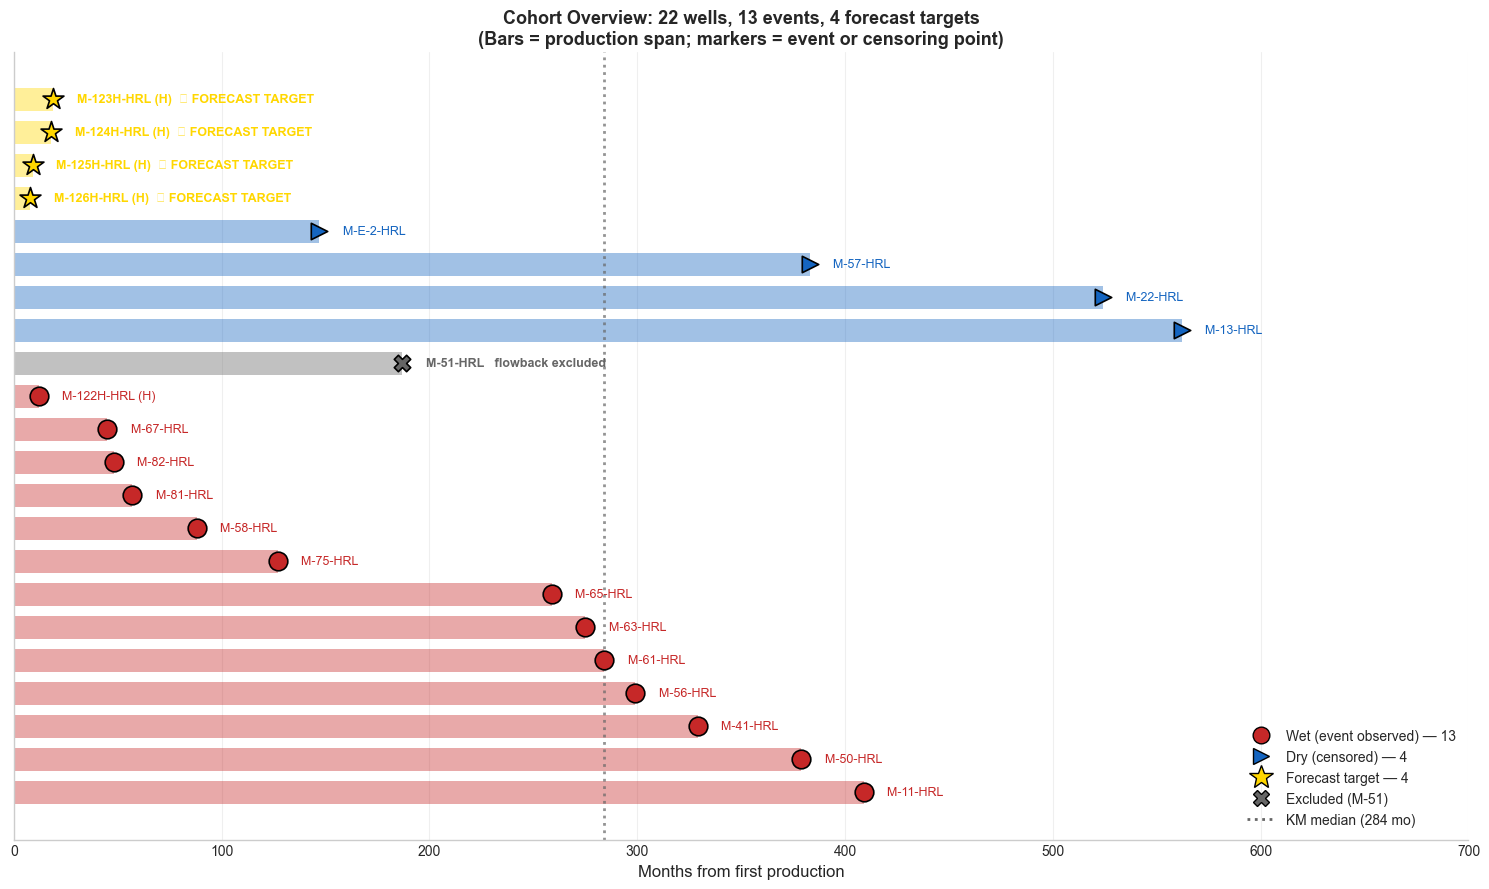

In [29]:
# === FIGURE: Cohort overview Gantt ===
from matplotlib.lines import Line2D

order = pd.concat([
    train_df[train_df['event_observed']==1].sort_values('time_to_event_months', ascending=False),
    pd.DataFrame([survival[survival['well'].isin(exclude_wells)].iloc[0]]) if exclude_wells else pd.DataFrame(),
    train_df[train_df['event_observed']==0].sort_values('time_to_event_months', ascending=False),
    forecast_df.sort_values('production_months'),
], ignore_index=True)

fig, ax = plt.subplots(figsize=(15, 9))
for i, r in order.iterrows():
    if r['well'] in exclude_wells:    color, mk, ms, st = GRAY, 'X', 140, 'excluded'
    elif r['well'] in forecast_wells: color, mk, ms, st = 'gold', '*', 250, 'TARGET'
    elif r['event_observed']==1:      color, mk, ms, st = RED, 'o', 180, 'wet'
    else:                              color, mk, ms, st = BLUE, '>', 140, 'dry'
    
    duration = r.get('production_months', r['time_to_event_months']) if pd.notna(r.get('production_months')) else r['time_to_event_months']
    ax.barh(i, r['time_to_event_months'], color=color, alpha=0.4, height=0.7)
    ax.scatter(r['time_to_event_months'], i, marker=mk, s=ms,
               color=color, edgecolor='black', linewidth=1.2, zorder=4)
    is_h = '(H)' if r.get('is_horizontal',0)==1 else ''
    label = f"  {r['well']} {is_h}"
    if st=='excluded':       label += '  flowback excluded'
    elif st=='TARGET':       label += '  ★ FORECAST TARGET'
    ax.text(r['time_to_event_months']+8, i, label, va='center', fontsize=9,
            color=color, fontweight='bold' if st in ('excluded','TARGET') else 'normal')

# KM median if we can compute
from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()
kmf.fit(train_df['time_to_event_months'], event_observed=train_df['event_observed'])
km_median = kmf.median_survival_time_
if not np.isinf(km_median):
    ax.axvline(km_median, color=GRAY, linestyle=':', linewidth=2, alpha=0.7,
               label=f'KM median: {km_median:.0f} mo')

ax.set_yticks([]); ax.set_xlabel('Months from first production', fontsize=12)
ax.set_xlim(0, max(700, order['time_to_event_months'].max()*1.15))
ax.set_title('Cohort Overview: 22 wells, 13 events, 4 forecast targets\n'
             '(Bars = production span; markers = event or censoring point)',
             fontsize=13, fontweight='bold')
ax.legend(handles=[
    Line2D([0],[0], marker='o', color='w', markerfacecolor=RED, markersize=12,
           markeredgecolor='black', label='Wet (event observed) — 13'),
    Line2D([0],[0], marker='>', color='w', markerfacecolor=BLUE, markersize=12,
           markeredgecolor='black', label='Dry (censored) — 4'),
    Line2D([0],[0], marker='*', color='w', markerfacecolor='gold', markersize=18,
           markeredgecolor='black', label='Forecast target — 4'),
    Line2D([0],[0], marker='X', color='w', markerfacecolor=GRAY, markersize=12,
           markeredgecolor='black', label='Excluded (M-51)'),
    Line2D([0],[0], color=GRAY, linestyle=':', linewidth=2, label=f'KM median ({km_median:.0f} mo)'),
], loc='lower right', fontsize=10, framealpha=0.95)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / '02_cohort_overview.png', dpi=140, bbox_inches='tight')
plt.show()

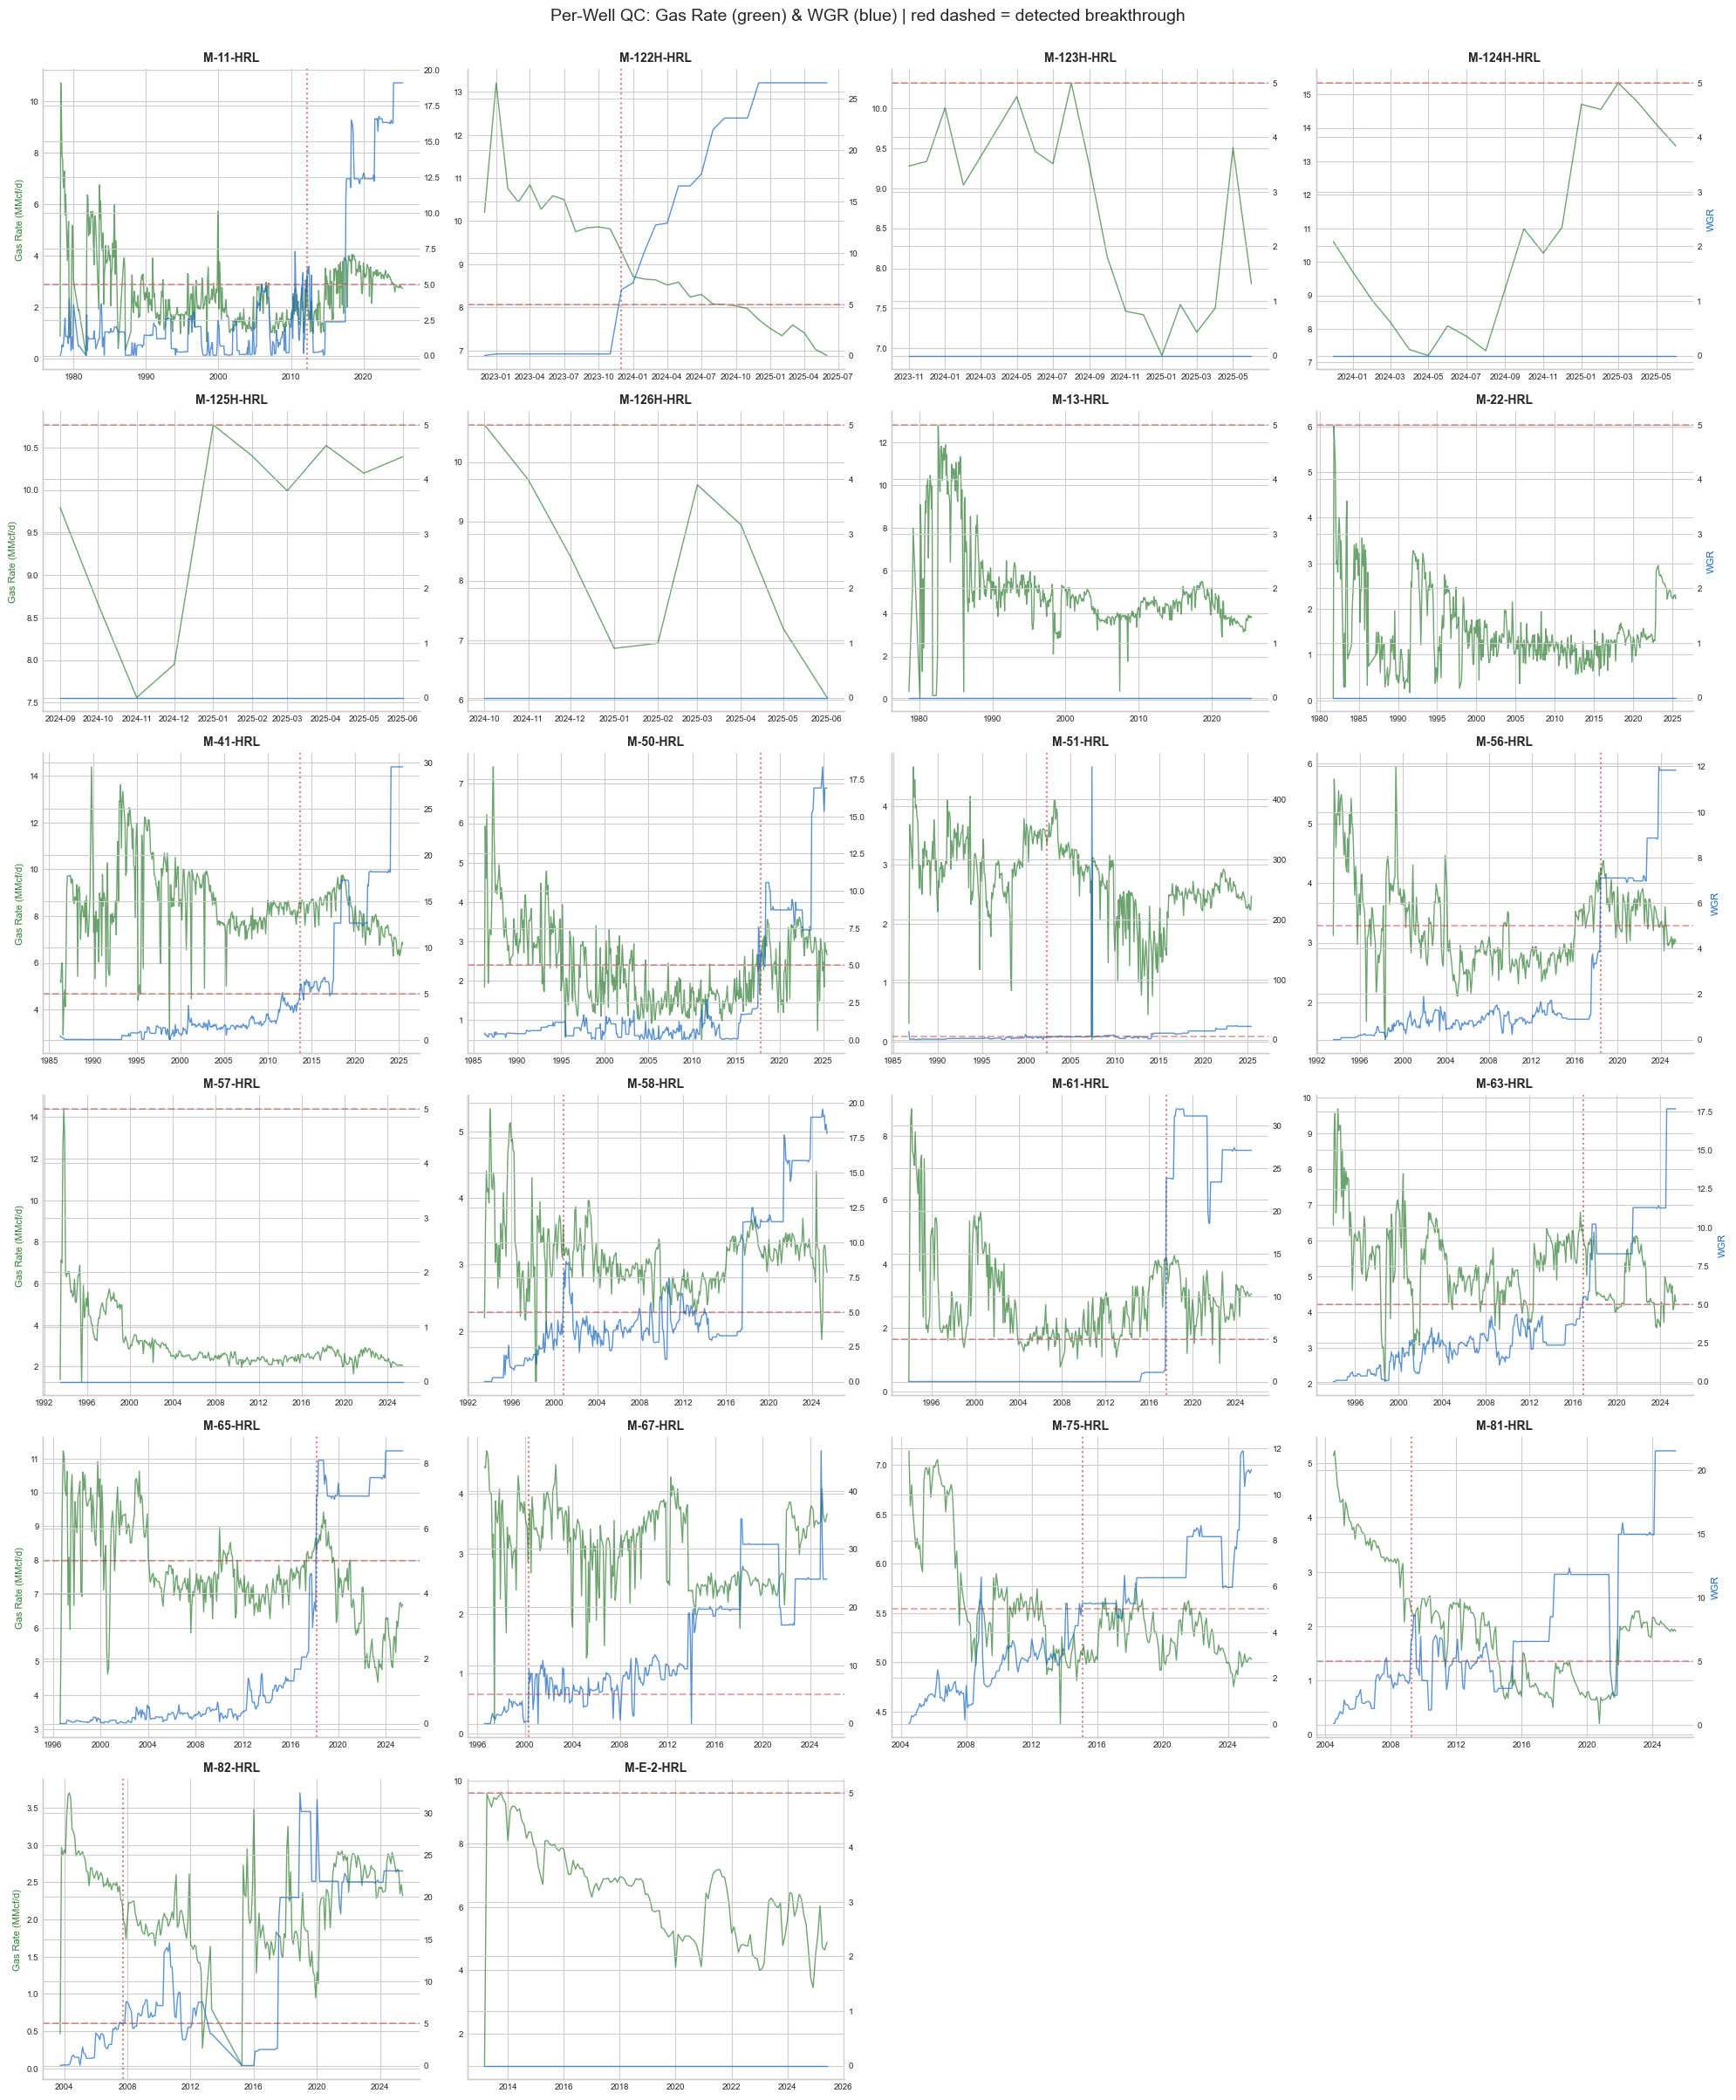

In [30]:
# === FIGURE: Per-well QC ===
wells_sorted = sorted(panel['well'].unique())
ncols=4; nrows=int(np.ceil(len(wells_sorted)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4*nrows), squeeze=False)
for idx, well in enumerate(wells_sorted):
    ax = axes[idx//ncols, idx%ncols]
    wd = panel[panel['well']==well].sort_values('date')
    wd = wd[wd['gas_mmcf']>0]
    if len(wd)==0:
        ax.set_visible(False); continue
    ax.plot(wd['date'], wd['gas_rate_mmcfd'], color=GREEN, alpha=0.7, linewidth=1, label='Gas Rate')
    ax2 = ax.twinx()
    ax2.plot(wd['date'], wd['wgr'], color=BLUE, alpha=0.7, linewidth=1, label='WGR')
    ax2.axhline(WGR_THRESHOLD, color=RED, linestyle='--', alpha=0.4, label=f'WGR={WGR_THRESHOLD}')
    if well in bt_results and bt_results[well]['event_observed']==1:
        bd = bt_results[well]['breakthrough_date']
        if bd is not None:
            ax.axvline(bd, color=RED, linestyle=':', alpha=0.6, linewidth=1.5)
    ax.set_title(well, fontsize=10, fontweight='bold')
    ax.tick_params(labelsize=7); ax2.tick_params(labelsize=7)
    if idx % ncols==0: ax.set_ylabel('Gas Rate (MMcf/d)', fontsize=8, color=GREEN)
    if idx % ncols==ncols-1: ax2.set_ylabel('WGR', fontsize=8, color=BLUE)
for idx in range(len(wells_sorted), nrows*ncols):
    axes[idx//ncols, idx%ncols].set_visible(False)
plt.suptitle('Per-Well QC: Gas Rate (green) & WGR (blue) | red dashed = detected breakthrough',
             fontsize=14, y=1.001)
plt.tight_layout()
plt.savefig(FIGURES / '03_per_well_qc.png', dpi=140, bbox_inches='tight')
plt.show()

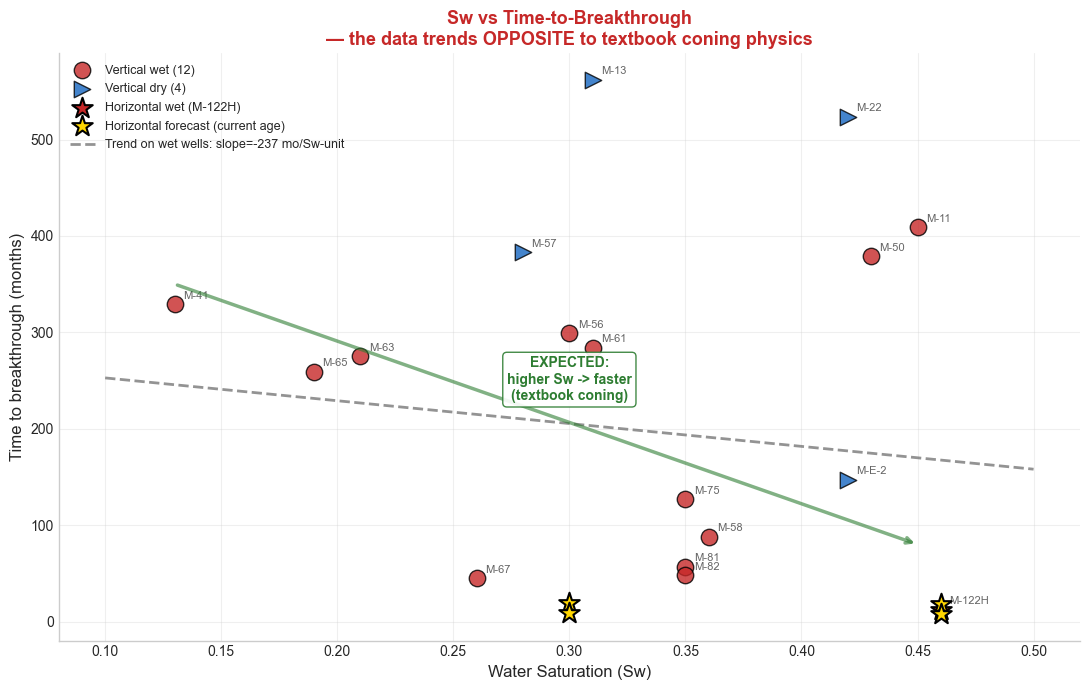

In [31]:
# === FIGURE: Sw vs Time-to-Event (the wrong-sign diagnostic) ===
fig, ax = plt.subplots(figsize=(11, 7))
wet_v = train_df[(train_df['event_observed']==1) & (train_df['is_horizontal']==0)]
dry_v = train_df[(train_df['event_observed']==0) & (train_df['is_horizontal']==0)]
horiz_wet = train_df[(train_df['event_observed']==1) & (train_df['is_horizontal']==1)]
fcst = forecast_df

ax.scatter(wet_v['sw'], wet_v['time_to_event_months'], s=140, color=RED, alpha=0.8,
           edgecolor='black', label=f'Vertical wet ({len(wet_v)})', zorder=3)
ax.scatter(dry_v['sw'], dry_v['time_to_event_months'], s=140, marker='>', color=BLUE,
           alpha=0.8, edgecolor='black', label=f'Vertical dry ({len(dry_v)})', zorder=3)
ax.scatter(horiz_wet['sw'], horiz_wet['time_to_event_months'], s=240, marker='*',
           color=RED, edgecolor='black', linewidth=1.5,
           label='Horizontal wet (M-122H)', zorder=4)
ax.scatter(fcst['sw'], fcst['production_months'], s=240, marker='*',
           color='gold', edgecolor='black', linewidth=1.5,
           label='Horizontal forecast (current age)', zorder=4)

# Trend on wet wells
all_wet = train_df[train_df['event_observed']==1]
if len(all_wet) >= 3:
    z = np.polyfit(all_wet['sw'], all_wet['time_to_event_months'], 1)
    xs = np.linspace(0.1, 0.5, 50)
    ax.plot(xs, np.poly1d(z)(xs), '--', color=GRAY, linewidth=2, alpha=0.7,
            label=f'Trend on wet wells: slope={z[0]:+.0f} mo/Sw-unit')

for _, r in train_df.iterrows():
    ax.annotate(r['well'].replace('-HRL',''), (r['sw'], r['time_to_event_months']),
                fontsize=8, xytext=(6,4), textcoords='offset points', color=GRAY)

ax.annotate('', xy=(0.45, 80), xytext=(0.13, 350),
            arrowprops=dict(arrowstyle='->', color=GREEN, lw=2.5, alpha=0.6))
ax.text(0.30, 230, 'EXPECTED:\nhigher Sw -> faster\n(textbook coning)', fontsize=10,
        color=GREEN, fontweight='bold', ha='center',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor=GREEN, alpha=0.9))

ax.set_xlabel('Water Saturation (Sw)', fontsize=12)
ax.set_ylabel('Time to breakthrough (months)', fontsize=12)
ax.set_title('Sw vs Time-to-Breakthrough\n— the data trends OPPOSITE to textbook coning physics',
             fontsize=13, color=RED)
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / '04_sw_vs_tte.png', dpi=140, bbox_inches='tight')
plt.show()

---
## 10. Kaplan-Meier Baseline

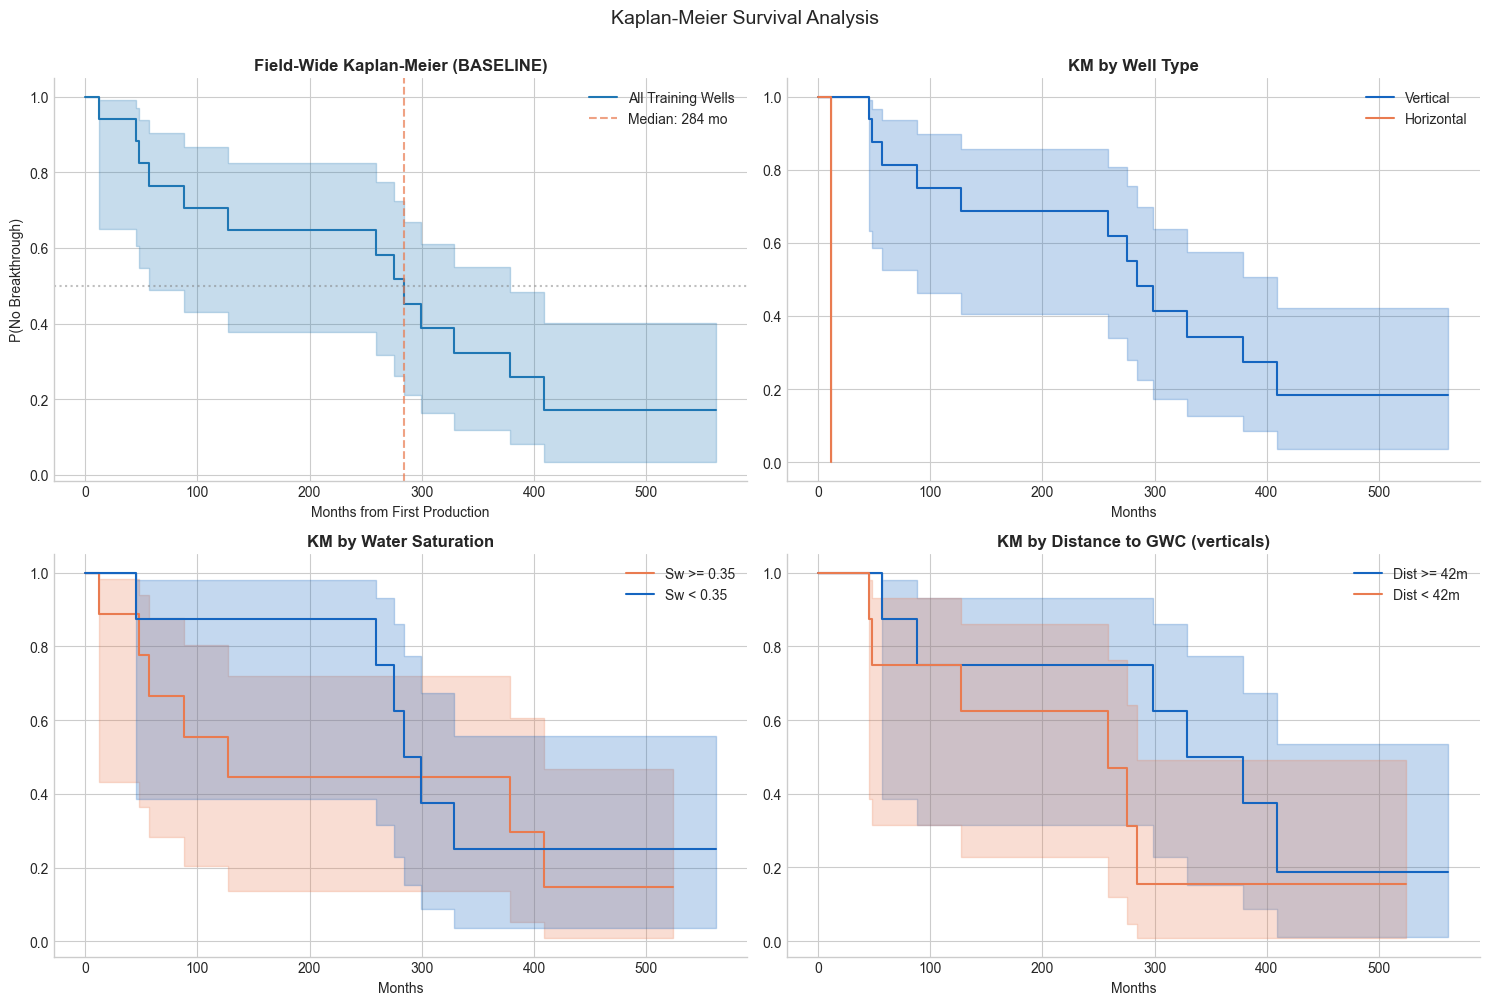


Field-wide KM median: 284.0 months


In [32]:
# === FIGURE: Kaplan-Meier ===
from lifelines.statistics import logrank_test
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

ax = axes[0,0]
kmf.fit(train_df['time_to_event_months'], event_observed=train_df['event_observed'],
        label='All Training Wells')
kmf.plot_survival_function(ax=ax, ci_show=True)
if not np.isinf(km_median):
    ax.axvline(km_median, color=ORANGE, linestyle='--', alpha=0.7,
               label=f'Median: {km_median:.0f} mo')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
ax.set_title('Field-Wide Kaplan-Meier (BASELINE)')
ax.set_xlabel('Months from First Production'); ax.set_ylabel('P(No Breakthrough)'); ax.legend()

ax = axes[0,1]
for wt, lbl, c in [(0,'Vertical',BLUE),(1,'Horizontal',ORANGE)]:
    m = train_df['is_horizontal']==wt
    if m.sum()>0:
        kmf.fit(train_df.loc[m,'time_to_event_months'], event_observed=train_df.loc[m,'event_observed'], label=lbl)
        kmf.plot_survival_function(ax=ax, color=c, ci_show=True)
ax.set_title('KM by Well Type'); ax.set_xlabel('Months'); ax.legend()

ax = axes[1,0]
sw_med = train_df['sw'].median()
for grp, lbl, c in [('high', f'Sw >= {sw_med:.2f}', ORANGE), ('low', f'Sw < {sw_med:.2f}', BLUE)]:
    m = (train_df['sw']>=sw_med) if grp=='high' else (train_df['sw']<sw_med)
    if m.sum()>0:
        kmf.fit(train_df.loc[m,'time_to_event_months'], event_observed=train_df.loc[m,'event_observed'], label=lbl)
        kmf.plot_survival_function(ax=ax, color=c, ci_show=True)
ax.set_title('KM by Water Saturation'); ax.set_xlabel('Months'); ax.legend()

ax = axes[1,1]
vert = train_df[train_df['is_horizontal']==0]
if len(vert)>1:
    dgwc_med = vert['dist_to_gwc_m'].median()
    for grp, lbl, c in [('far', f'Dist >= {dgwc_med:.0f}m', BLUE),
                        ('near', f'Dist < {dgwc_med:.0f}m', ORANGE)]:
        m = (vert['dist_to_gwc_m']>=dgwc_med) if grp=='far' else (vert['dist_to_gwc_m']<dgwc_med)
        if m.sum()>0:
            kmf.fit(vert.loc[m,'time_to_event_months'], event_observed=vert.loc[m,'event_observed'], label=lbl)
            kmf.plot_survival_function(ax=ax, color=c, ci_show=True)
    ax.set_title('KM by Distance to GWC (verticals)'); ax.set_xlabel('Months'); ax.legend()

plt.suptitle('Kaplan-Meier Survival Analysis', fontsize=14, y=1.001)
plt.tight_layout()
plt.savefig(FIGURES / '05_kaplan_meier.png', dpi=140, bbox_inches='tight')
plt.show()
print(f'\nField-wide KM median: {km_median:.1f} months')

---
## 11. Cox PH and Weibull AFT (with robust mu_ extraction)

Adds `get_aft_mu_params()` helper that handles both flat and MultiIndex `params_` across lifelines versions, fixing the prior `KeyError: 'mu_'`.

In [33]:
def get_aft_mu_params(model):
    """Robust mu_ (location) parameter extraction across lifelines versions."""
    p = model.params_
    if isinstance(p.index, pd.MultiIndex):
        for key in ['mu_','lambda_','alpha_']:
            if key in p.index.get_level_values(0):
                s = p.xs(key, level=0)
                # Drop intercept/scale if present
                return s.drop(['Intercept','_intercept'], errors='ignore')
        first_level = p.index.get_level_values(0)[0]
        return p.xs(first_level, level=0).drop(['Intercept','_intercept'], errors='ignore')
    return p.drop(['Intercept','_intercept','rho_'], errors='ignore')

cox_features = ['sw','log_perm','dist_to_gwc_m','log_gas_rate']

cox_data = train_df[['well','time_to_event_months','event_observed'] + cox_features].dropna(subset=cox_features)
print(f'Cox data: {len(cox_data)} wells, {int(cox_data["event_observed"].sum())} events, '
      f'EPV={cox_data["event_observed"].sum()/len(cox_features):.2f}')

cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_data[['time_to_event_months','event_observed'] + cox_features],
        duration_col='time_to_event_months', event_col='event_observed')
print('\n=== COX PH ==='); cph.print_summary()
print(f'\nC-index: {cph.concordance_index_:.3f}')

Cox data: 17 wells, 13 events, EPV=3.25

=== COX PH ===


<lifelines.CoxPHFitter: fitted with 17 total observations, 4 right-censored observations>
             duration col = 'time_to_event_months'
                event col = 'event_observed'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 17
number of events observed = 13
   partial log-likelihood = -26.06
         time fit was run = 2026-04-16 04:12:43 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
sw            -3.45      0.03      3.38          -10.07            3.17                0.00               23.86
log_perm      -0.36      0.70      0.53           -1.40            0.67                0.25                1.96
dist_to_gwc_m -0.07      0.94      0.03           -0.12           -0.01                0.89                0.99
log_gas_rate   0.19      1.21      0.79           -1.36            1.74                0.26                5.69

               cmp to     z    p  -log2(p)
covariate                                 
sw               0.00 -1.02 0.31      1.70
log_perm         0.00 -0.68 0.49      1.02
dist_to_gwc_m    0.00 -2.27 0.02      5.43
log_gas_rate     0.00  0.24 0.81      0.30
---
Concordance = 0.79
Partial AIC = 60.13
log-likelihood ratio test = 5.93 on 4 df
-log2(p) of ll-ratio test = 2.29


C-index: 0.787


In [34]:
# Cox sign check
print('=== COX PH PHYSICS SIGN CHECK ===\n')
expected_signs = {'sw':'positive','log_perm':'positive','dist_to_gwc_m':'negative','log_gas_rate':'positive'}
hr = np.exp(cph.params_)
physics_ok = True
for f, exp in expected_signs.items():
    if f not in cph.params_.index: continue
    coef = cph.params_[f]
    actual = 'positive' if coef>0 else 'negative'
    ok = (actual==exp)
    if not ok: physics_ok = False
    print(f'  {f:18s}: coef={coef:+.3f}, HR={hr[f]:.3f}, '
          f'expected={exp:9s}, actual={actual:9s} -> {"OK" if ok else "WRONG"}')
print(f'\nAll signs OK: {physics_ok}')

=== COX PH PHYSICS SIGN CHECK ===

  sw                : coef=-3.450, HR=0.032, expected=positive , actual=negative  -> WRONG
  log_perm          : coef=-0.361, HR=0.697, expected=positive , actual=negative  -> WRONG
  dist_to_gwc_m     : coef=-0.065, HR=0.937, expected=negative , actual=negative  -> OK
  log_gas_rate      : coef=+0.188, HR=1.207, expected=positive , actual=positive  -> OK

All signs OK: False


In [35]:
# Weibull AFT with robust sign extraction
aft_features = cox_features
aft_data = train_df[['well','time_to_event_months','event_observed']+aft_features].dropna(subset=aft_features)

waft = WeibullAFTFitter(penalizer=0.01)
waft.fit(aft_data[['time_to_event_months','event_observed']+aft_features],
         duration_col='time_to_event_months', event_col='event_observed')
print('=== WEIBULL AFT ==='); waft.print_summary()

print('\n=== AFT PHYSICS SIGN CHECK (positive coef = LONGER time = protective) ===\n')
expected_aft = {'sw':'negative','log_perm':'negative','dist_to_gwc_m':'positive','log_gas_rate':'negative'}
mu_p = get_aft_mu_params(waft)
print(f'mu_p index: {list(mu_p.index)}\n')
aft_physics_ok = True
for f, exp in expected_aft.items():
    if f not in mu_p.index:
        print(f'  {f}: not in model'); continue
    coef = mu_p[f]; actual='positive' if coef>0 else 'negative'
    ok = actual==exp
    if not ok: aft_physics_ok=False
    print(f'  {f:18s}: coef={coef:+.4f}, expected={exp:9s}, actual={actual:9s} -> {"OK" if ok else "WRONG"}')
print(f'\nAll AFT signs OK: {aft_physics_ok}')

=== WEIBULL AFT ===


<lifelines.WeibullAFTFitter: fitted with 17 total observations, 4 right-censored observations>
             duration col = 'time_to_event_months'
                event col = 'event_observed'
                penalizer = 0.01
   number of observations = 17
number of events observed = 13
           log-likelihood = -85.00
         time fit was run = 2026-04-16 04:12:58 UTC

---
                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                      
lambda_ dist_to_gwc_m  0.06      1.06      0.02            0.01            0.10                1.01                1.11
        log_gas_rate  -0.08      0.92      0.73           -1.50            1.34                0.22                3.81
        log_perm       0.55      1.74      0.53           -0.49            1.60                0.61                4.95
        sw             2.95     19.05      3.03           -2.99            8.88                0.05             7189.26
        Intercept      1.10      3.01      2.76           -4.31            6.52                0.01              675.63
rho_    Intercept      0.30      1.34      0.22           -0.14            0.73                0.87                2.08

                       cmp to     z    p  -log2(p)
param   covariate                                 
lambda_ dist_to_gwc_m    0.00  2.38 0.02      5.84
        log_gas_rate     0.00 -0.12 0.91      0.14
        log_perm         0.00  1.03 0.30      1.73
        sw               0.00  0.97 0.33      1.60
        Intercept        0.00  0.40 0.69      0.54
rho_    Intercept        0.00  1.32 0.19      2.42
---
Concordance = 0.80
AIC = 182.01
log-likelihood ratio test = 6.18 on 4 df
-log2(p) of ll-ratio test = 2.43


=== AFT PHYSICS SIGN CHECK (positive coef = LONGER time = protective) ===

mu_p index: ['dist_to_gwc_m', 'log_gas_rate', 'log_perm', 'sw']

  sw                : coef=+2.9470, expected=negative , actual=positive  -> WRONG
  log_perm          : coef=+0.5525, expected=negative , actual=positive  -> WRONG
  dist_to_gwc_m     : coef=+0.0571, expected=positive , actual=positive  -> OK
  log_gas_rate      : coef=-0.0836, expected=negative , actual=negative  -> OK

All AFT signs OK: False


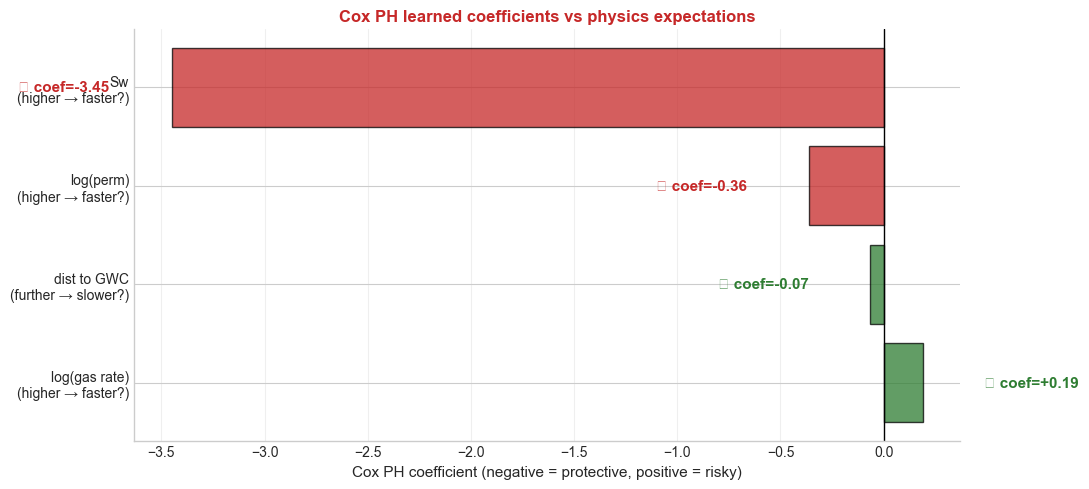

In [36]:
# === FIGURE: Cox coefficients with sign check ===
fig, ax = plt.subplots(figsize=(11, 5))
feats_disp = ['Sw\n(higher → faster?)', 'log(perm)\n(higher → faster?)',
              'dist to GWC\n(further → slower?)', 'log(gas rate)\n(higher → faster?)']
coefs = [cph.params_[f] for f in cox_features]
exp_dirs = [+1,+1,-1,+1]  # expected sign in Cox: positive coef = higher hazard
act_dirs = [1 if c>0 else -1 for c in coefs]
colors = [RED if a!=e else GREEN for a,e in zip(act_dirs, exp_dirs)]

bars = ax.barh(feats_disp, coefs, color=colors, alpha=0.75, edgecolor='black')
for b, c, e, a in zip(bars, coefs, exp_dirs, act_dirs):
    sym = '✓' if a==e else '✗'
    ax.text(c + (0.3 if c>0 else -0.3), b.get_y()+b.get_height()/2,
            f'{sym} coef={c:+.2f}', va='center',
            ha='left' if c>0 else 'right',
            fontweight='bold', fontsize=11,
            color=GREEN if a==e else RED)

ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Cox PH coefficient (negative = protective, positive = risky)', fontsize=11)
ax.set_title('Cox PH learned coefficients vs physics expectations',
             fontsize=12, color=RED if not physics_ok else GREEN)
ax.invert_yaxis(); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / '06_cox_signs.png', dpi=140, bbox_inches='tight')
plt.show()

In [37]:
# AFT model comparison
aft_comp = []
for name, mdl in [('Weibull AFT',WeibullAFTFitter(penalizer=0.01)),
                  ('LogNormal AFT',LogNormalAFTFitter(penalizer=0.01)),
                  ('LogLogistic AFT',LogLogisticAFTFitter(penalizer=0.01))]:
    try:
        mdl.fit(aft_data[['time_to_event_months','event_observed']+aft_features],
                duration_col='time_to_event_months', event_col='event_observed')
        aft_comp.append({'Model':name,'AIC':mdl.AIC_,'BIC':mdl.BIC_,'C-Index':mdl.concordance_index_})
    except Exception as e:
        print(f'{name}: FAILED - {e}')
print(pd.DataFrame(aft_comp).sort_values('AIC').to_string(index=False))

          Model        AIC        BIC  C-Index
LogLogistic AFT 179.542712 173.209139 0.786885
  LogNormal AFT 179.782570 173.448997 0.762295
    Weibull AFT 182.009061 175.675488 0.795082


---
## 12. Random Survival Forest (with permutation importance)

RSF C-index in-sample: 0.861
RSF C-index OOB:       0.492

RSF OOB <= random. Trees overfit; primary models remain Cox/Weibull AFT.

Permutation importances:
  dist_to_gwc_m     : +0.3451 +/- 0.0779
  log_perm          : +0.0410 +/- 0.0127
  log_gas_rate      : +0.0336 +/- 0.0202
  sw                : +0.0197 +/- 0.0180


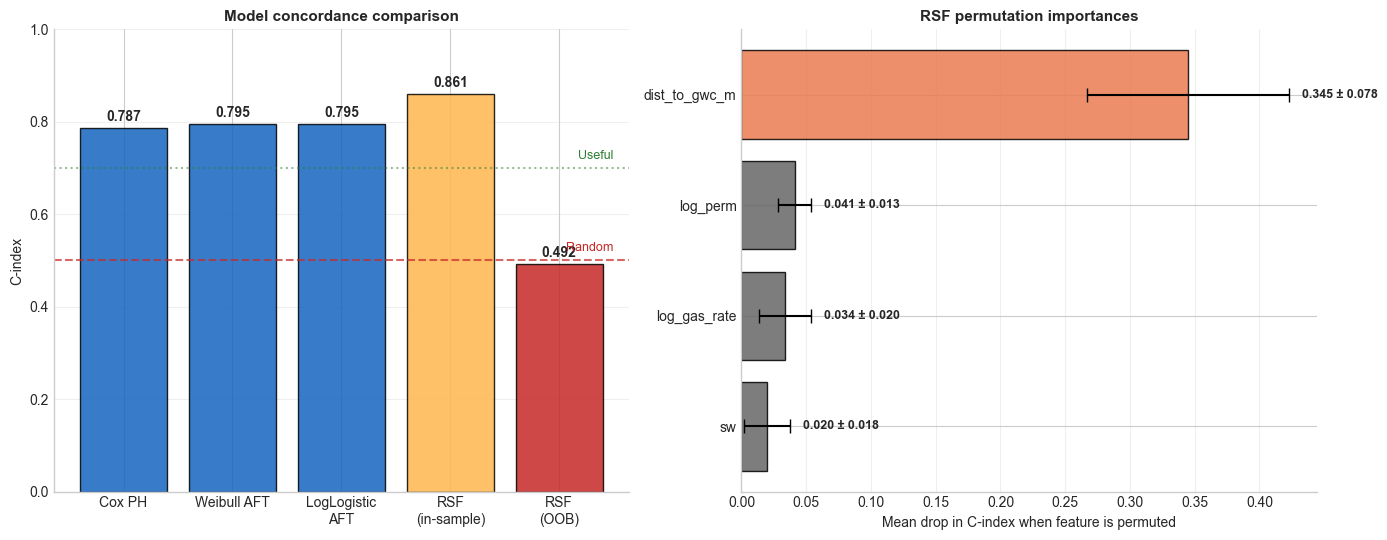

In [38]:
if HAS_SKSURV:
    from sksurv.metrics import concordance_index_censored
    from sklearn.inspection import permutation_importance

    rsf_data = train_df[cox_features+['time_to_event_months','event_observed']].dropna()
    X_rsf = rsf_data[cox_features].values
    y_rsf = Surv.from_arrays(event=rsf_data['event_observed'].astype(bool),
                             time=rsf_data['time_to_event_months'])
    rsf = RandomSurvivalForest(n_estimators=300, min_samples_split=5,
                               min_samples_leaf=3, max_depth=3, max_features='sqrt',
                               oob_score=True, random_state=42, n_jobs=-1)
    rsf.fit(X_rsf, y_rsf)
    rsf_in = rsf.score(X_rsf, y_rsf); rsf_oob = rsf.oob_score_
    print(f'RSF C-index in-sample: {rsf_in:.3f}')
    print(f'RSF C-index OOB:       {rsf_oob:.3f}')
    if rsf_oob < 0.55:
        print('\nRSF OOB <= random. Trees overfit; primary models remain Cox/Weibull AFT.')

    perm_imp = permutation_importance(rsf, X_rsf, y_rsf, n_repeats=10, random_state=42, n_jobs=-1)
    importances = pd.Series(perm_imp.importances_mean, index=cox_features)
    importances_std = pd.Series(perm_imp.importances_std, index=cox_features)
    print('\nPermutation importances:')
    for f in importances.sort_values(ascending=False).index:
        print(f'  {f:18s}: {importances[f]:+.4f} +/- {importances_std[f]:.4f}')

    # === FIGURE: model comparison + permutation importance ===
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    ax = axes[0]
    labs  = ['Cox PH','Weibull AFT','LogLogistic\nAFT','RSF\n(in-sample)','RSF\n(OOB)']
    cidx  = [cph.concordance_index_, waft.concordance_index_, 
             aft_comp[0]['C-Index'] if aft_comp else 0.75, rsf_in, rsf_oob]
    cols = [BLUE,BLUE,BLUE,'#FFB74D', RED if rsf_oob<0.5 else BLUE]
    bars = ax.bar(labs, cidx, color=cols, edgecolor='black', alpha=0.85)
    for b, c in zip(bars, cidx):
        ax.text(b.get_x()+b.get_width()/2, c+0.015, f'{c:.3f}', ha='center', fontweight='bold')
    ax.axhline(0.5, color=RED, linestyle='--', alpha=0.7); ax.text(4.5, 0.52, 'Random', color=RED, fontsize=9, ha='right')
    ax.axhline(0.7, color=GREEN, linestyle=':', alpha=0.5); ax.text(4.5, 0.72, 'Useful', color=GREEN, fontsize=9, ha='right')
    ax.set_ylabel('C-index'); ax.set_ylim(0,1); ax.set_title('Model concordance comparison', fontsize=11)
    ax.grid(axis='y', alpha=0.3)

    ax = axes[1]
    srt = importances.sort_values()
    cols = [ORANGE if f=='dist_to_gwc_m' else GRAY for f in srt.index]
    bars = ax.barh(srt.index, srt.values, xerr=importances_std.reindex(srt.index),
                   color=cols, edgecolor='black', alpha=0.85, capsize=5)
    for b, v, s in zip(bars, srt.values, importances_std.reindex(srt.index)):
        ax.text(v+s+0.01, b.get_y()+b.get_height()/2, f'{v:.3f} ± {s:.3f}',
                va='center', fontsize=9, fontweight='bold')
    ax.set_xlabel('Mean drop in C-index when feature is permuted')
    ax.set_title('RSF permutation importances', fontsize=11)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES / '07_rsf_diagnostics.png', dpi=140, bbox_inches='tight')
    plt.show()
    rsf_cindex = rsf_oob
else:
    rsf=None; rsf_cindex=None

---
## 13. Physics-Constrained Model

Tries to force correct signs while maintaining a C-index floor of 0.65. Uses the robust `get_aft_mu_params` helper.

In [39]:
CINDEX_FLOOR = 0.65

def signs_correct(model, expected, fit_features):
    mu_p = get_aft_mu_params(model)
    for f, exp in expected.items():
        if f not in fit_features or f not in mu_p.index: continue
        coef = mu_p[f]; actual='positive' if coef>0 else 'negative'
        if actual != exp: return False
    return True

best_constrained_model = None; best_penalty = None; best_features = None
for penalty in [0.01,0.05,0.1,0.5,1.0,2.0,5.0]:
    try:
        m = WeibullAFTFitter(penalizer=penalty)
        m.fit(aft_data[['time_to_event_months','event_observed']+aft_features],
              duration_col='time_to_event_months', event_col='event_observed')
        ok = signs_correct(m, expected_aft, aft_features)
        ci = m.concordance_index_
        marker = 'PASS' if (ok and ci>=CINDEX_FLOOR) else ('signs OK,C low' if ok else 'wrong signs')
        print(f'penalty={penalty:5.2f}  C={ci:.3f}  signs_ok={ok}  -> {marker}')
        if ok and ci>=CINDEX_FLOOR:
            best_constrained_model=m; best_penalty=penalty; best_features=aft_features; break
    except Exception as e: print(f'penalty={penalty}: {e}')

if best_constrained_model is None:
    print('\nFalling back to reduced 3-feature set...')
    reduced = ['sw','dist_to_gwc_m','log_gas_rate']
    reduced_signs = {k:v for k,v in expected_aft.items() if k in reduced}
    for penalty in [0.01,0.1,0.5,1.0,2.0]:
        rd = aft_data[['time_to_event_months','event_observed']+reduced].dropna()
        try:
            m = WeibullAFTFitter(penalizer=penalty)
            m.fit(rd, duration_col='time_to_event_months', event_col='event_observed')
            ok = signs_correct(m, reduced_signs, reduced)
            ci = m.concordance_index_
            print(f'reduced penalty={penalty:5.2f}  C={ci:.3f}  signs_ok={ok}')
            if ok and ci>=CINDEX_FLOOR:
                best_constrained_model=m; best_penalty=penalty; best_features=reduced; break
        except Exception as e: print(f'reduced penalty={penalty}: {e}')

if best_constrained_model is None:
    print('\nNo physics-consistent model found. Using vanilla Weibull as final.')
    best_constrained_model = waft; best_penalty=0.01; best_features=aft_features
else:
    print(f'\nFinal physics-constrained model:')
    print(f'  features={best_features}, penalty={best_penalty}, C={best_constrained_model.concordance_index_:.3f}')

penalty= 0.01  C=0.795  signs_ok=False  -> wrong signs
penalty= 0.05  C=0.803  signs_ok=False  -> wrong signs
penalty= 0.10  C=0.803  signs_ok=False  -> wrong signs
penalty= 0.50  C=0.795  signs_ok=False  -> wrong signs
penalty= 1.00  C=0.754  signs_ok=False  -> wrong signs
penalty= 2.00  C=0.721  signs_ok=False  -> wrong signs
penalty= 5.00  C=0.705  signs_ok=False  -> wrong signs

Falling back to reduced 3-feature set...
reduced penalty= 0.01  C=0.803  signs_ok=False
reduced penalty= 0.10  C=0.787  signs_ok=False
reduced penalty= 0.50  C=0.754  signs_ok=False
reduced penalty= 1.00  C=0.738  signs_ok=False
reduced penalty= 2.00  C=0.713  signs_ok=False

No physics-consistent model found. Using vanilla Weibull as final.


---
## 14. P10 / P50 / P90 Forecasts

In [40]:
def predict_percentiles(model, features_df, feature_cols):
    results = []
    for idx, row in features_df.iterrows():
        X = row[feature_cols].to_frame().T
        try:
            sf = model.predict_survival_function(X)
            times = sf.index.values.astype(float)
            probs = sf.values.flatten()
            probs_rev = probs[::-1]; times_rev = times[::-1]
            p90 = float(np.interp(0.90, probs_rev, times_rev))
            p50 = float(np.interp(0.50, probs_rev, times_rev))
            p10 = float(np.interp(0.10, probs_rev, times_rev))
            p90 = max(0.5, p90); p50 = max(p90+0.5, p50); p10 = max(p50+0.5, p10)
            results.append({'well':row.get('well',idx),
                            'P90_months':round(p90,1),'P50_months':round(p50,1),
                            'P10_months':round(p10,1),
                            'survival_times':times,'survival_probs':probs})
        except Exception as e:
            print(f'Prediction failed for {row.get("well",idx)}: {e}')
            results.append({'well':row.get('well',idx),
                            'P90_months':np.nan,'P50_months':np.nan,'P10_months':np.nan})
    return pd.DataFrame(results)

final_model = best_constrained_model
final_features = best_features
print(f'Final model: {type(final_model).__name__}, features={final_features}')

# Forecasts
forecasts = predict_percentiles(final_model, forecast_df, final_features)
print('\n=== P10 / P50 / P90 FORECASTS ===\n')
print(forecasts[['well','P90_months','P50_months','P10_months']].to_string(index=False))
print(f'\nKM baseline median: {km_median:.0f} mo')
for _, r in forecasts.iterrows():
    diff = r['P50_months'] - km_median
    direction = 'earlier' if diff<0 else 'later'
    print(f"  {r['well']:14s} P50={r['P50_months']:6.0f} mo "
          f"({abs(diff):.0f} mo {direction} than baseline)")

Final model: WeibullAFTFitter, features=['sw', 'log_perm', 'dist_to_gwc_m', 'log_gas_rate']

=== P10 / P50 / P90 FORECASTS ===

      well  P90_months  P50_months  P10_months
M-123H-HRL        13.9        57.2       140.5
M-124H-HRL        27.5       116.8       283.5
M-125H-HRL        14.0        57.3       140.8
M-126H-HRL        27.5       116.6       283.1

KM baseline median: 284 mo
  M-123H-HRL     P50=    57 mo (227 mo earlier than baseline)
  M-124H-HRL     P50=   117 mo (167 mo earlier than baseline)
  M-125H-HRL     P50=    57 mo (227 mo earlier than baseline)
  M-126H-HRL     P50=   117 mo (167 mo earlier than baseline)


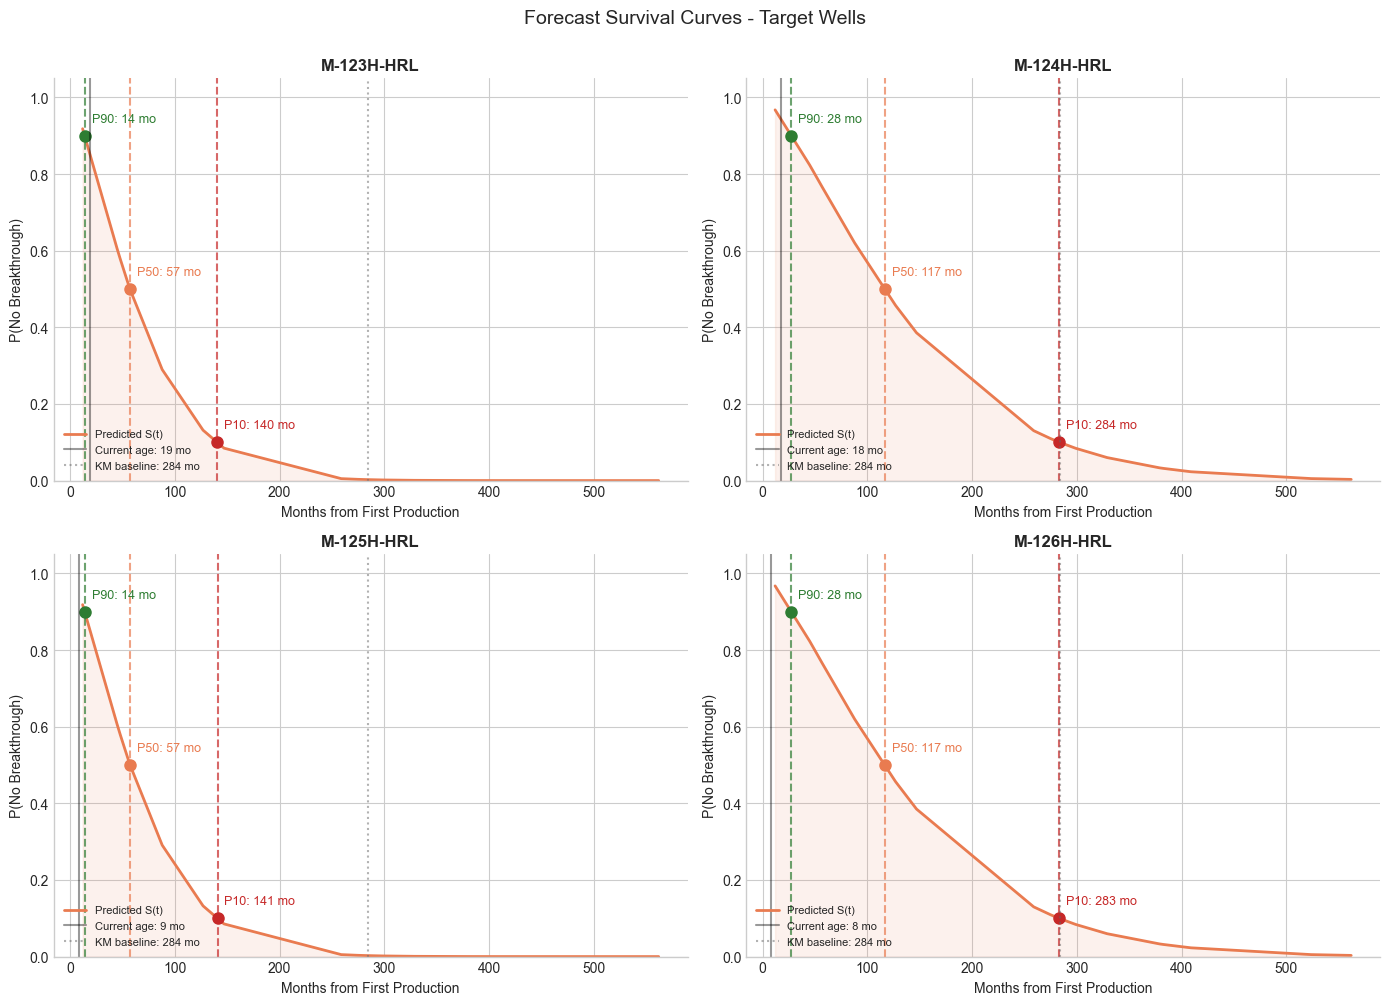

In [41]:
# === FIGURE: Forecast survival curves ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
forecast_age = {r['well']: r['production_months'] for _, r in forecast_df.iterrows()}
for idx, (_, row) in enumerate(forecasts.iterrows()):
    if idx>=4: break
    ax = axes[idx//2, idx%2]
    if 'survival_times' in row and row['survival_times'] is not None:
        ax.plot(row['survival_times'], row['survival_probs'], color=ORANGE, linewidth=2, label='Predicted S(t)')
        ax.fill_between(row['survival_times'], row['survival_probs'], alpha=0.1, color=ORANGE)
    for pval, prob, c, lbl in [(row['P90_months'],0.9,GREEN,'P90'),
                                (row['P50_months'],0.5,ORANGE,'P50'),
                                (row['P10_months'],0.1,RED,'P10')]:
        ax.axvline(pval, color=c, linestyle='--', alpha=0.7)
        ax.plot(pval, prob, 'o', color=c, markersize=8)
        ax.annotate(f'{lbl}: {pval:.0f} mo', xy=(pval,prob), xytext=(5,10),
                    textcoords='offset points', fontsize=9, color=c)
    cur = forecast_age.get(row['well'], 0)
    if cur>0:
        ax.axvline(cur, color='black', alpha=0.4, linewidth=1.5, label=f'Current age: {cur:.0f} mo')
    if not np.isinf(km_median):
        ax.axvline(km_median, color=GRAY, linestyle=':', alpha=0.5, label=f'KM baseline: {km_median:.0f} mo')
    ax.set_title(row['well'], fontsize=12, fontweight='bold')
    ax.set_xlabel('Months from First Production'); ax.set_ylabel('P(No Breakthrough)')
    ax.set_ylim(0, 1.05); ax.legend(fontsize=8, loc='lower left')
plt.suptitle('Forecast Survival Curves - Target Wells', fontsize=14, y=1.001)
plt.tight_layout()
plt.savefig(FIGURES / '08_forecast_curves.png', dpi=140, bbox_inches='tight')
plt.show()

---
## 15. Leave-One-Out Validation

In [42]:
# Leave-one-out
loo_preds = []
for idx in train_df.index:
    train_loo = train_df.drop(idx); test_loo = train_df.loc[[idx]]
    fit_d = train_loo[['time_to_event_months','event_observed']+final_features].dropna()
    if len(fit_d)<3 or fit_d['event_observed'].sum()<2: continue
    try:
        m = WeibullAFTFitter(penalizer=best_penalty or 0.1)
        m.fit(fit_d, duration_col='time_to_event_months', event_col='event_observed')
        pred = predict_percentiles(m, test_loo, final_features)
        loo_preds.append({
            'well':test_loo['well'].values[0],
            'event':int(test_loo['event_observed'].values[0]),
            'actual_months':float(test_loo['time_to_event_months'].values[0]),
            'pred_p50':pred['P50_months'].values[0],
            'pred_p10':pred['P10_months'].values[0],
            'pred_p90':pred['P90_months'].values[0],
            'is_horizontal':int(test_loo['is_horizontal'].values[0]),
        })
    except Exception as e: print(f'LOO failed for {test_loo["well"].values[0]}: {e}')

loo_df = pd.DataFrame(loo_preds)
events_only = loo_df[loo_df['event']==1].copy()
events_only['abs_error'] = (events_only['pred_p50'] - events_only['actual_months']).abs()
events_only['within_p90_p10'] = ((events_only['pred_p90']<=events_only['actual_months']) &
                                  (events_only['actual_months']<=events_only['pred_p10']))
print(f'=== LOO RESULTS ({len(events_only)} events) ===\n')
print(events_only[['well','actual_months','pred_p90','pred_p50','pred_p10',
                   'abs_error','within_p90_p10']].to_string(index=False))
print(f'\nMedian absolute error (P50): {events_only["abs_error"].median():.1f} months')
print(f'Coverage of P90-P10: {events_only["within_p90_p10"].mean()*100:.0f}% (target 80%)')

m122 = events_only[events_only['well'].str.contains('122H', na=False)]
if len(m122)>0:
    r = m122.iloc[0]
    print(f'\n=== M-122H HORIZONTAL VALIDATION (HELD OUT) ===')
    print(f'  Actual: {r["actual_months"]:.0f} mo')
    print(f'  P50 pred: {r["pred_p50"]:.0f} mo (error: {r["abs_error"]:.0f} mo)')
    print(f'  P90-P10: [{r["pred_p90"]:.0f}, {r["pred_p10"]:.0f}]')
    print(f'  Within P90-P10: {r["within_p90_p10"]}')

=== LOO RESULTS (13 events) ===

      well  actual_months  pred_p90  pred_p50  pred_p10  abs_error  within_p90_p10
  M-11-HRL          409.0     169.7     562.0     562.5      153.0            True
M-122H-HRL           12.0     127.5     404.7     562.0      392.7           False
  M-41-HRL          329.0     177.2     562.0     562.5      233.0            True
  M-50-HRL          379.0     346.7     562.0     562.5      183.0            True
  M-56-HRL          299.0     105.7     456.0     562.0      157.0            True
  M-58-HRL           88.0      78.1     308.4     562.0      220.4            True
  M-61-HRL          284.0      42.9     193.3     490.3       90.7            True
  M-63-HRL          275.0      33.7     149.2     378.1      125.8            True
  M-65-HRL          258.9      25.1     110.5     274.7      148.4            True
  M-67-HRL           45.0      31.5     128.0     304.3       83.0            True
  M-75-HRL          127.0      31.6     139.7     353.

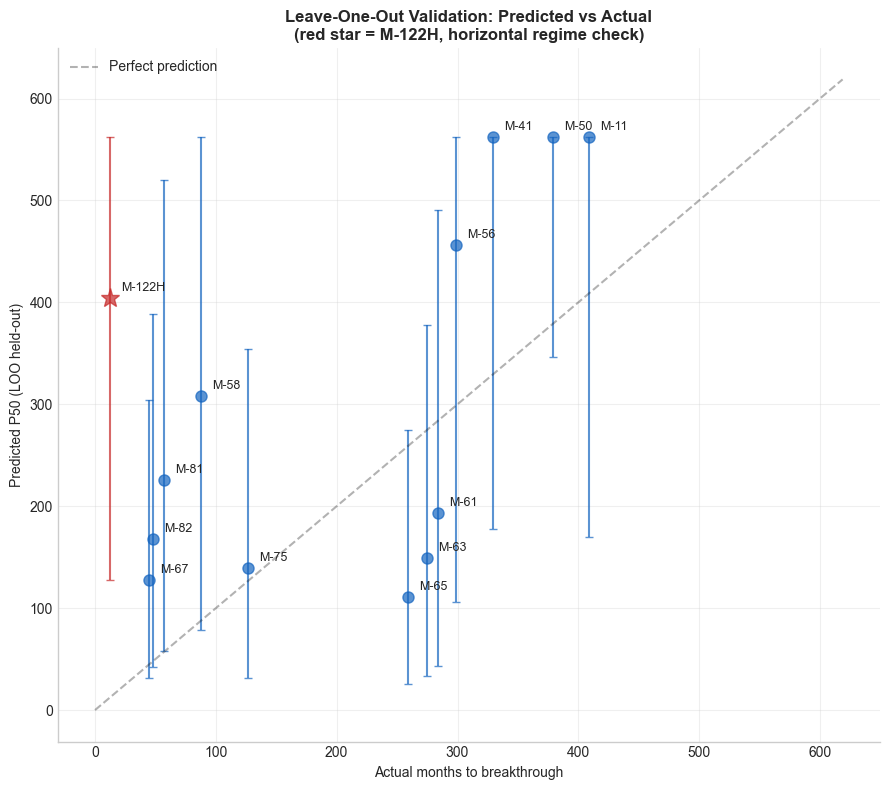

In [43]:
# === FIGURE: LOO predicted vs actual ===
fig, ax = plt.subplots(figsize=(9,8))
for _, r in events_only.iterrows():
    color = RED if '122H' in str(r['well']) else BLUE
    marker = '*' if '122H' in str(r['well']) else 'o'
    ax.errorbar(r['actual_months'], r['pred_p50'],
                yerr=[[max(0, r['pred_p50']-r['pred_p90'])],
                      [max(0, r['pred_p10']-r['pred_p50'])]],
                fmt=marker, color=color, capsize=3, markersize=14 if marker=='*' else 8, alpha=0.7)
    ax.annotate(str(r['well']).replace('-HRL',''), (r['actual_months'], r['pred_p50']),
                fontsize=9, xytext=(8,5), textcoords='offset points')
mv = max(events_only['actual_months'].max(), events_only['pred_p10'].max())*1.1
ax.plot([0,mv],[0,mv],'k--', alpha=0.3, label='Perfect prediction')
ax.set_xlabel('Actual months to breakthrough'); ax.set_ylabel('Predicted P50 (LOO held-out)')
ax.set_title('Leave-One-Out Validation: Predicted vs Actual\n(red star = M-122H, horizontal regime check)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / '09_loo_validation.png', dpi=140, bbox_inches='tight')
plt.show()

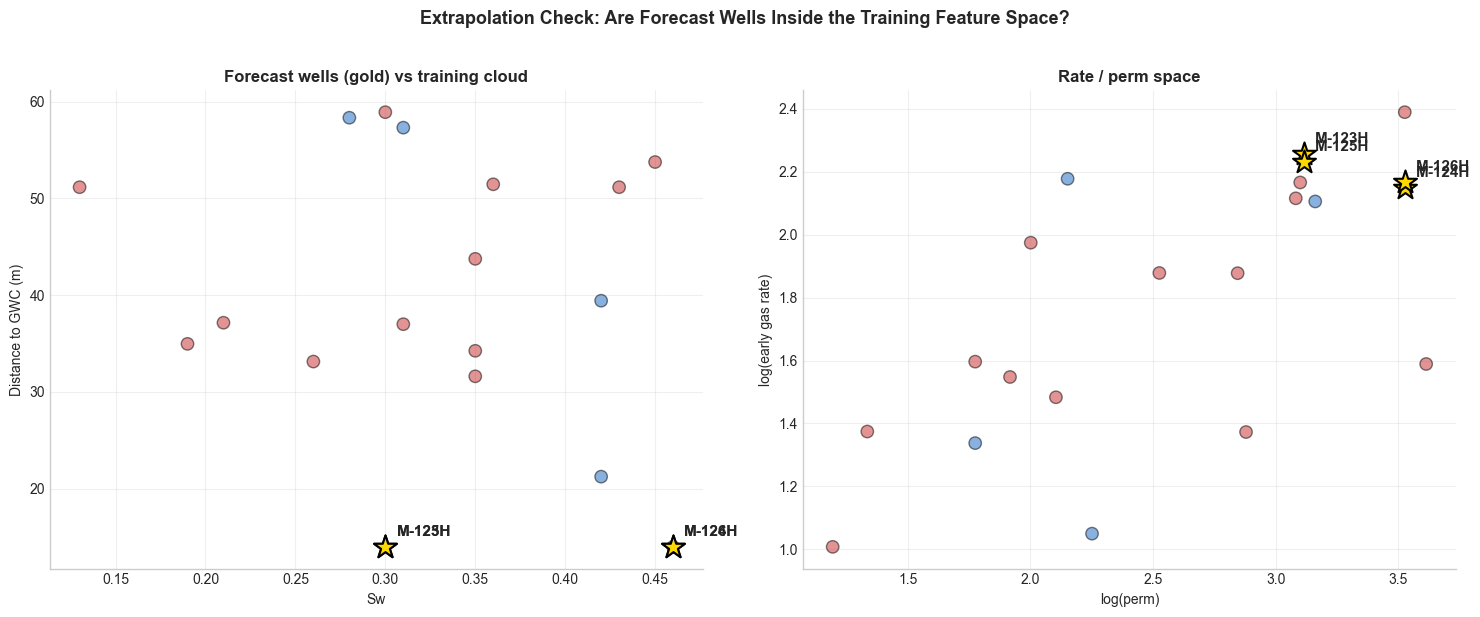

=== EXTRAPOLATION SUMMARY ===

M-123H-HRL: 0 extrapolation flag(s)
M-124H-HRL: 0 extrapolation flag(s)
M-125H-HRL: 0 extrapolation flag(s)
M-126H-HRL: 0 extrapolation flag(s)


In [44]:
# === FIGURE: Extrapolation check ===
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ax = axes[0]
colors = [RED if e==1 else BLUE for e in train_df['event_observed']]
ax.scatter(train_df['sw'], train_df['dist_to_gwc_m'], s=80, c=colors, alpha=0.5,
           edgecolor='black', label='Training (red=wet, blue=dry)')
for _, r in forecast_df.iterrows():
    ax.scatter(r['sw'], r['dist_to_gwc_m'], s=300, marker='*', color='gold',
               edgecolor='black', linewidth=1.5, zorder=10)
    ax.annotate(str(r['well']).replace('-HRL',''), (r['sw'], r['dist_to_gwc_m']),
                fontsize=11, fontweight='bold', xytext=(8,8), textcoords='offset points')
ax.set_xlabel('Sw'); ax.set_ylabel('Distance to GWC (m)')
ax.set_title('Forecast wells (gold) vs training cloud'); ax.grid(alpha=0.3)

ax = axes[1]
ax.scatter(train_df['log_perm'], train_df['log_gas_rate'], s=80, c=colors, alpha=0.5, edgecolor='black')
for _, r in forecast_df.iterrows():
    ax.scatter(r['log_perm'], r['log_gas_rate'], s=300, marker='*', color='gold',
               edgecolor='black', linewidth=1.5, zorder=10)
    ax.annotate(str(r['well']).replace('-HRL',''), (r['log_perm'], r['log_gas_rate']),
                fontsize=11, fontweight='bold', xytext=(8,8), textcoords='offset points')
ax.set_xlabel('log(perm)'); ax.set_ylabel('log(early gas rate)')
ax.set_title('Rate / perm space'); ax.grid(alpha=0.3)
plt.suptitle('Extrapolation Check: Are Forecast Wells Inside the Training Feature Space?',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / '10_extrapolation_check.png', dpi=140, bbox_inches='tight')
plt.show()

print('=== EXTRAPOLATION SUMMARY ===\n')
for _, fr in forecast_df.iterrows():
    flags = []
    for f in ['sw','dist_to_gwc_m','log_perm','log_gas_rate']:
        tn, tx = train_df[f].min(), train_df[f].max()
        if pd.notna(fr[f]) and (fr[f]<tn or fr[f]>tx):
            flags.append(f'{f} OUT-OF-RANGE')
    print(f'{fr["well"]}: {len(flags)} extrapolation flag(s)')
    for fl in flags: print(f'    - {fl}')

---
## 16. Summary, Open Questions, Next Steps

In [45]:
print('='*70)
print(' MARI WATER BREAKTHROUGH PREDICTION - RUN SUMMARY')
print('='*70)
print(f'\nPanel: {len(panel)} well-months, {panel["date"].min().date()} to {panel["date"].max().date()}')
print(f'Wells: {panel["well"].nunique()} ({len(forecast_df)} forecast targets)')
print(f'\nGWC scenario adopted: B (datum-corrected, GWC = {GWC_TVD:.0f} m RKB)')
print(f'Cox PH C-index: {cph.concordance_index_:.3f} | physics signs OK: {physics_ok}')
print(f'Weibull AFT C-index: {waft.concordance_index_:.3f} | physics signs OK: {aft_physics_ok}')
print(f'Final model: {type(final_model).__name__}, features={final_features}')
if 'events_only' in dir() and len(events_only)>0:
    print(f'LOO MAE: {events_only["abs_error"].median():.0f} months, '
          f'P90-P10 coverage: {events_only["within_p90_p10"].mean()*100:.0f}%')

print(f'\n--- FORECASTS (P10/P50/P90 in months) ---')
for _, r in forecasts.iterrows():
    print(f"  {r['well']:14s} P90={r['P90_months']:6.0f}   P50={r['P50_months']:6.0f}   P10={r['P10_months']:6.0f}")

print('\n--- OPEN ITEMS REQUIRING MARI INPUT ---')
print('1. CONFIRM GWC datum reference: subsea (TVD-SS) or RKB-relative?')
print('   - We assumed TVD-SS and added 70m mean RKB elevation -> GWC = 754m RKB')
print('   - If RKB-relative, all verticals are below GWC (physically impossible)')
print('2. CONFIRM well M-51 perforation interval and completion notes (water from month 0)')
print('3. VERIFY new horizontals (M-123H/124H/125H/126H) target same Zone A as legacy verticals,')
print('   or a deeper Zone B (Habib Rahi B in completion sketches)')
print('4. PROVIDE engineering "first water" dates per wet well (replaces WGR>5 inferred labels)')
print('5. PROVIDE pre-Aug 2015 choke records and pre-Jun 1990 WHFP for archived wells')

print(f'\nAll figures saved to: {FIGURES.resolve()}')

 MARI WATER BREAKTHROUGH PREDICTION - RUN SUMMARY

Panel: 6652 well-months, 1978-03-01 to 2025-06-01
Wells: 22 (4 forecast targets)

GWC scenario adopted: B (datum-corrected, GWC = 754 m RKB)
Cox PH C-index: 0.787 | physics signs OK: False
Weibull AFT C-index: 0.795 | physics signs OK: False
Final model: WeibullAFTFitter, features=['sw', 'log_perm', 'dist_to_gwc_m', 'log_gas_rate']
LOO MAE: 153 months, P90-P10 coverage: 85%

--- FORECASTS (P10/P50/P90 in months) ---
  M-123H-HRL     P90=    14   P50=    57   P10=   140
  M-124H-HRL     P90=    28   P50=   117   P10=   284
  M-125H-HRL     P90=    14   P50=    57   P10=   141
  M-126H-HRL     P90=    28   P50=   117   P10=   283

--- OPEN ITEMS REQUIRING MARI INPUT ---
1. CONFIRM GWC datum reference: subsea (TVD-SS) or RKB-relative?
   - We assumed TVD-SS and added 70m mean RKB elevation -> GWC = 754m RKB
   - If RKB-relative, all verticals are below GWC (physically impossible)
2. CONFIRM well M-51 perforation interval and completion no

---
## 17. Output guide for non-technical readers

Everything in `figures_v2/` is ready to drop into a presentation. Here's what each figure shows in plain English:

| File | What it shows |
|---|---|
| `01_gwc_datum_scenarios.png` | Every vertical well's perforation depth plotted against two possible GWC interpretations. Confirms the datum mismatch issue. |
| `02_cohort_overview.png` | Gantt-style timeline showing which wells produced for how long, when each broke through, and which are forecast targets. |
| `03_per_well_qc.png` | Production curve for every well — gas rate (green) and water-gas ratio (blue). Red dashed line marks detected breakthrough. Use to spot data anomalies. |
| `04_sw_vs_tte.png` | Scatter showing the wrong-physics-sign issue: wells with low Sw broke through earlier than wells with high Sw, opposite of textbook coning. |
| `05_kaplan_meier.png` | The non-parametric "survival curve" baseline. The 50% line crossing point is the median time-to-breakthrough. |
| `06_cox_signs.png` | Cox model coefficients with green/red colour for whether each feature has the physically expected sign. |
| `07_rsf_diagnostics.png` | Random Survival Forest — in-sample vs OOB C-index (overfitting check), plus permutation importance. |
| `08_forecast_curves.png` | The headline result: P10/P50/P90 breakthrough forecasts for each of the 4 target wells. |
| `09_loo_validation.png` | Leave-one-out predicted vs actual scatter. Red star = M-122H (held out). |
| `10_extrapolation_check.png` | Are the forecast wells inside the training feature space? Gold stars far from the cloud = extrapolation = wider uncertainty. |